In [1]:
import xarray as xr
import matplotlib.pyplot as plt
from cmocean import cm # for oceanography-specific colormaps
from scipy.io import loadmat
import numpy as np
import re
from xml.etree import ElementTree as ET
from matplotlib.path import Path
import pandas as pd
## cross corr and spectrum
from statsmodels.tsa.stattools import ccf
from scipy.signal import coherence, csd
from scipy.fft import fftfreq
import statsmodels.api as sm
from scipy import signal

In [2]:
ds = xr.open_dataset('../../NHCS/hincast_1980-2015/croco_avg_Y1980M01.nc', 
                     chunks = {'time':1})
ds

<xarray.Dataset> Size: 891MB
Dimensions:     (xi_rho: 602, xi_u: 601, eta_rho: 542, eta_v: 541, s_rho: 32,
                 s_w: 33, time: 1, auxil: 4)
Coordinates: (12/13)
  * xi_rho      (xi_rho) float64 5kB 1.0 2.0 3.0 4.0 ... 599.0 600.0 601.0 602.0
  * xi_u        (xi_u) float64 5kB 1.5 2.5 3.5 4.5 ... 598.5 599.5 600.5 601.5
  * eta_rho     (eta_rho) float64 4kB 1.0 2.0 3.0 4.0 ... 540.0 541.0 542.0
  * eta_v       (eta_v) float64 4kB 1.5 2.5 3.5 4.5 ... 538.5 539.5 540.5 541.5
  * s_rho       (s_rho) float64 256B -0.9844 -0.9531 ... -0.04688 -0.01562
  * s_w         (s_w) float64 264B -1.0 -0.9688 -0.9375 ... -0.0625 -0.03125 0.0
    ...          ...
    lat_rho     (eta_rho, xi_rho) float64 3MB dask.array<chunksize=(542, 602), meta=np.ndarray>
    lon_u       (eta_rho, xi_u) float64 3MB dask.array<chunksize=(542, 601), meta=np.ndarray>
    lat_u       (eta_rho, xi_u) float64 3MB dask.array<chunksize=(542, 601), meta=np.ndarray>
    lon_v       (eta_v, xi_rho) float64 3MB dask.array<chunksize=(541, 602), meta=np.ndarray>
    lat_v       (eta_v, xi_rho) float64 3MB dask.array<chunksize=(541, 602), meta=np.ndarray>
  * time        (time) float32 4B 1.339e+06
Dimensions without coordinates: auxil
Data variables: (12/54)
    spherical   |S1 1B ...
    xl          float64 8B ...
    el          float64 8B ...
    Vtransform  float64 8B ...
    sc_r        (s_rho) float64 256B dask.array<chunksize=(32,), meta=np.ndarray>
    sc_w        (s_w) float64 264B dask.array<chunksize=(33,), meta=np.ndarray>
    ...          ...
    swflux      (time, eta_rho, xi_rho) float32 1MB dask.array<chunksize=(1, 542, 602), meta=np.ndarray>
    radsw       (time, eta_rho, xi_rho) float32 1MB dask.array<chunksize=(1, 542, 602), meta=np.ndarray>
    shflx_rlw   (time, eta_rho, xi_rho) float32 1MB dask.array<chunksize=(1, 542, 602), meta=np.ndarray>
    shflx_lat   (time, eta_rho, xi_rho) float32 1MB dask.array<chunksize=(1, 542, 602), meta=np.ndarray>
    shflx_sen   (time, eta_rho, xi_rho) float32 1MB dask.array<chunksize=(1, 542, 602), meta=np.ndarray>
    hel         (time, eta_rho, xi_rho) float32 1MB dask.array<chunksize=(1, 542, 602), meta=np.ndarray>
Attributes: (12/57)
    type:           ROMS restart file
    title:          Peru UW Interannual Run
    date:           
    rst_file:       croco_rst.nc
    his_file:       croco_his.nc
    avg_file:       croco_avg.nc
    ...             ...
    gamma2_expl:    Slipperiness parameter
    x_sponge:       0.0
    v_sponge:       0.0
    sponge_expl:    Sponge parameters : extent (m) & viscosity (m2.s-1)
    SRCS:           main.F step.F read_inp.F timers_roms.F init_scalars.F ini...
    CPP-options:    REGIONAL PERU_UW MPI OBC_WEST OBC_NORTH OBC_SOUTH BIOLOGY...

In [3]:
SST = loadmat("../../NHCS/Processed/SST_SSH.mat")
print(SST.keys())

dict_keys(['__header__', '__version__', '__globals__', 'SSH', 'SST'])


In [4]:
print(ds.mask_rho.shape)
mask_rho = ds.mask_rho.values 
mask_nan = np.where(mask_rho, 1, np.nan)
expanded_mask = np.tile(mask_nan[np.newaxis, :, :], (432, 1, 1))

(542, 602)


In [5]:
time = pd.date_range(start="1980-01",end="2016-01",freq='M')

ds_temp = xr.Dataset(
    data_vars={
        'SST':(("time", "lat","lon"), SST['SST'].transpose(2, 1, 0)*expanded_mask),
    },
    coords = {
        'lon':ds.lon_rho.compute().values[0,:],
        'lat':ds.lat_rho.compute().values[:,0],
        'time':time
}
)
ds_temp

/tmp/ipykernel_2277849/1721827683.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  time = pd.date_range(start="1980-01",end="2016-01",freq='M')


<xarray.Dataset> Size: 1GB
Dimensions:  (time: 432, lat: 542, lon: 602)
Coordinates:
  * lon      (lon) float64 5kB -119.0 -118.9 -118.8 ... -69.03 -68.95 -68.87
  * lat      (lat) float64 4kB -33.0 -32.93 -32.86 -32.79 ... 9.869 9.951 10.03
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
Data variables:
    SST      (time, lat, lon) float64 1GB 20.19 20.18 20.24 ... nan nan nan

## Functions

In [6]:
## kml to struct
import re
from xml.etree import ElementTree as ET
import numpy as np

def kml2struct(kml_file):
    """
    Import a .kml file as a list of dictionary structures with fields:
    Geometry, Name, Description, Lon, Lat, and BoundingBox.
    """
    # Read the KML file
    try:
        with open(kml_file, 'r', encoding='utf-8') as file:
            txt = file.read()
    except Exception as e:
        raise FileNotFoundError(f"Unable to open file {kml_file}: {e}")

    # Regular expression to match Placemark tags
    expr = r"<Placemark.+?>.+?</Placemark>"
    object_strings = re.findall(expr, txt, re.DOTALL)
    
    kml_struct = []

    for obj_str in object_strings:
        # Extract Name
        name_match = re.search(r"<name.*?>(.*?)</name>", obj_str, re.DOTALL)
        name = name_match.group(1).strip() if name_match else "undefined"

        # Extract Description
        desc_match = re.search(r"<description.*?>(.*?)</description>", obj_str, re.DOTALL)
        desc = desc_match.group(1).strip() if desc_match else ""

        # Determine Geometry Type
        geometry = ""
        if "<Point" in obj_str:
            geometry = "Point"
        elif "<LineString" in obj_str:
            geometry = "Line"
        elif "<Polygon" in obj_str:
            geometry = "Polygon"

        # Extract Coordinates
        coord_match = re.search(r"<coordinates.*?>(.*?)</coordinates>", obj_str, re.DOTALL)
        if not coord_match:
            continue  # Skip if no coordinates are found
        coord_str = coord_match.group(1).strip()
        coord_list = np.array([list(map(float, coord.split(','))) for coord in coord_str.split()])

        # Separate Lon, Lat, and handle Polygons
        lon = coord_list[:, 0]
        lat = coord_list[:, 1]
        if geometry == "Polygon":
            # Close the polygon by appending NaN
            lon = np.append(lon, np.nan)
            lat = np.append(lat, np.nan)

        # Create BoundingBox
        bounding_box = [[lon.min(), lat.min()], [lon.max(), lat.max()]]

        # Append to kml_struct
        kml_struct.append({
            "Geometry": geometry,
            "Name": name,
            "Description": desc,
            "Lon": lon,
            "Lat": lat,
            "BoundingBox": bounding_box
        })

    return kml_struct

In [7]:
# Load the KML file to get the polygon boundary
arch_kml_zona1 = "../../NHCS/hindcast/CROCO_BioEBUS_1990-2010/indices/BK111km.kml"
R1 = kml2struct(arch_kml_zona1)

# Extract Lon and Lat from the first polygon
lonb1 = R1[0]["Lon"]
latb1 = R1[0]["Lat"]

In [8]:
from matplotlib.path import Path
LON, LAT = np.meshgrid(ds_temp.lon,ds_temp.lat)
# Create a path from the polygon coordinates
polygon = Path(np.column_stack((lonb1, latb1)))

# Flatten the LON and LAT to create coordinate pairs
lonlat_points = np.column_stack((LON.ravel(), LAT.ravel()))

# Check which points are inside the polygon
mask = polygon.contains_points(lonlat_points).reshape(LON.shape)

# Convert the mask to NaN for the outshore region
inshore_mask = np.where(mask, 1, np.nan)

In [9]:
##ports
Puertos = {
       "Pisco":  [-13.69388889,  -76.22416667],
    "Callao":   [-12.0575,  -77.15305556],
    "Chimbote": [-9.076666667,  -78.61472222],
    "Paita":    [-5.078055556,  -81.10638889],
    }

### Crosscorr 

In [10]:
# import numpy as np
# import matplotlib.pyplot as plt
# import statsmodels.api as sm
# from scipy import signal

# def normalize(data):
#     return (data - data.min()) / (data.max() - data.min())

# def zscore(x):
#     return (x - x.mean()) / x.std()

# def analyze_correlation_and_spectrum(df, x_col, y_col, lags=100, nperseg=256, xlim=None):
#     """
#     Conventions:
#     - Cross-correlation R_xy[τ] = Corr(X_t, Y_{t+τ})
#       τ > 0 ⇒ X leads Y; τ < 0 ⇒ Y leads X.
#     - CSD S_xy = CSD(X, Y); phase = arg(S_xy) is the phase of Y relative to X.
#       Positive phase ⇒ X leads Y at that frequency.
#     """
#     x = df[x_col].to_numpy()
#     y = df[y_col].to_numpy()

#     # Time series (normalized for visibility)
#     plt.figure(figsize=(12, 4))
#     plt.plot(normalize(x), label=x_col, alpha=0.8)
#     plt.plot(normalize(y), label=y_col, alpha=0.8)
#     if xlim is not None:
#         plt.xlim(0, xlim)
#     plt.title(f"Time Series: {x_col} (X) and {y_col} (Y)")
#     plt.legend()
#     plt.grid(True, alpha=0.3)
#     plt.show()

#     # Autocorrelation of X (z-scored)
#     autocorr_x = sm.tsa.acf(zscore(x), nlags=lags)

#     # Symmetric cross-correlation R_xy with clear convention
#     # statsmodels.ccf(a,b) returns Corr(a_t, b_{t+τ}) for τ ≥ 0
#     r_xy_pos = sm.tsa.ccf(zscore(x), zscore(y), adjusted=False)[:lags+1]  # τ = 0..+lags
#     r_yx_pos = sm.tsa.ccf(zscore(y), zscore(x), adjusted=False)[:lags+1]  # τ = 0..+lags
#     # Negative τ: R_xy[-k] = Corr(Y_t, X_{t+k}) = r_yx_pos[k]
#     r_xy_neg = r_yx_pos[1:][::-1]  # τ = -1..-lags
#     r_xy = np.concatenate([r_xy_neg, r_xy_pos])  # length 2*lags+1
#     taus = np.arange(-lags, lags+1)

#     # Top peaks (by magnitude)
#     mag = np.abs(r_xy)
#     top_idxs = np.argsort(mag)[-3:][::-1]
#     print("\nTop 3 cross-correlation peaks (τ>0: X leads Y):")
#     for idx in top_idxs:
#         print(f"r = {r_xy[idx]:.3f} | τ = {taus[idx]}")

#     # Primary peak
#     k_peak = int(np.argmax(mag))
#     tau_peak = int(taus[k_peak])
#     corr_peak = float(r_xy[k_peak])
#     if tau_peak > 0:
#         lead_text = f"{x_col} leads {y_col} by {tau_peak} step(s)"
#     elif tau_peak < 0:
#         lead_text = f"{y_col} leads {x_col} by {abs(tau_peak)} step(s)"
#     else:
#         lead_text = "Peak at τ=0 (no lead/lag)"

#     # Cross-correlation and autocorrelation plot
#     plt.figure(figsize=(7, 4.8))
#     plt.stem(taus, r_xy, basefmt=" ", linefmt="C1-", markerfmt="C1o",
#              label=fr"$R_{{{x_col},{y_col}}}(\tau)$")
#     plt.axvline(0, color='k', lw=1)
#     # mirror autocorr for context
#     plt.plot(np.arange(0, lags+1), autocorr_x, 'C0-', alpha=0.7,
#              label=fr"$\rho_{{{x_col}{x_col}}}$ (auto)")
#     plt.plot(-np.arange(0, lags+1), autocorr_x, 'C0-', alpha=0.7)
#     plt.title(f"Cross-correlation (τ>0: {x_col} leads {y_col}) — {lead_text}")
#     plt.xlabel("Lag τ [steps]")
#     plt.ylabel("Correlation")
#     plt.legend()
#     plt.grid(True, alpha=0.3)
#     plt.show()

#     # Spectral analysis — consistent ordering: (X, Y)
#     fxx, Pxx = signal.welch(x, nperseg=nperseg)
#     fyy, Pyy = signal.welch(y, nperseg=nperseg)
#     fxy, Sxy = signal.csd(x, y, nperseg=nperseg)  # CSD(X,Y)
#     fcoh, Cxy = signal.coherence(x, y, nperseg=nperseg)

#     phase_deg = np.angle(Sxy, deg=True)  # phase of Y relative to X
#     # unwrap for readability
#     phase_deg = np.rad2deg(np.unwrap(np.deg2rad(phase_deg)))

#     # Coherence, phase, PSD
#     fig, axs = plt.subplots(1, 3, figsize=(13, 3.8))

#     axs[0].semilogx(fcoh, Cxy, 'C0-')
#     axs[0].set_title(f"Coherence ({x_col} vs {y_col})")
#     axs[0].set_xlabel("Frequency [1/step]")
#     axs[0].set_ylabel("Coherence")
#     axs[0].set_ylim(0, 1)
#     axs[0].grid(True, which='both', ls='--', alpha=0.4)

#     axs[1].semilogx(fxy, phase_deg, 'C2-')
#     axs[1].axhline(0, color='k', lw=1)
#     axs[1].set_title(f"Phase of {y_col} relative to {x_col}\n(>0: {x_col} leads, <0: {y_col} leads)")
#     axs[1].set_xlabel("Frequency [1/step]")
#     axs[1].set_ylabel("Phase [deg]")
#     axs[1].grid(True, which='both', ls='--', alpha=0.4)

#     axs[2].semilogx(fxx, Pxx, label=x_col)
#     axs[2].semilogx(fyy, Pyy, label=y_col)
#     axs[2].set_title("Power Spectral Density")
#     axs[2].set_xlabel("Frequency [1/step]")
#     axs[2].set_ylabel("Power")
#     axs[2].legend()
#     axs[2].grid(True, which='both', ls='--', alpha=0.4)

#     plt.tight_layout()
#     plt.show()

#     print(f"\nSummary: peak cross-corr at τ = {tau_peak} (value {corr_peak:.3f}). {lead_text}.")

In [11]:
def normalize(data):
    return (data - data.min()) / (data.max() - data.min())

def zscore(x):
    return (x - x.mean()) / x.std()
    
def analyze_correlation_and_spectrum(df, x_col, y_col, lags=int, nperseg=int, xlim=500):
    """
    Plot time series, autocorrelation, cross-correlation, coherence, phase, and PSD
    between two signals in a DataFrame.

    Parameters:
        df (pd.DataFrame): DataFrame containing time series data
        x_col (str): Name of the X (reference) column
        y_col (str): Name of the Y (target) column
        lags (int): Number of lags for correlation functions
        nperseg (int): Segment length for spectral analysis
        xlim (int): Optional limit for time series plot
    """
    
    x = df[x_col]
    y = df[y_col]

    # Plot time series
    plt.figure(figsize=(12, 5))
    plt.plot(normalize(x), label=x_col, alpha=0.7)
    plt.plot(normalize(y), label=y_col, alpha=0.7)
    plt.title(f"Time Series Plot: {y_col} vs {x_col}")
    # plt.xlim(0, xlim)
    plt.legend()
    plt.grid(True)
    plt.show()

    # Autocorrelation of x
    autocorr = sm.tsa.acf(zscore(x), nlags=lags)

    # Cross-correlations
    crosscorr_xy = sm.tsa.ccf(zscore(y), zscore(x), adjusted=False)[:lags]
    crosscorr_yx = sm.tsa.ccf(zscore(x), zscore(y), adjusted=False)[:lags]

    # top lags
    cross_corr = np.concatenate([crosscorr_xy, crosscorr_yx])
    lags_array = np.concatenate([-np.arange(lags-1, -1, -1), np.arange(1, lags)])

        #top 3 peaks
    top_idxs = np.argsort(np.abs(cross_corr))[-3:][::-1]
    print("\nTop 3 cross-correlation peaks:")
    for idx in top_idxs:
        print(f"r = {cross_corr[idx]:.3f}  |  lag = {lags_array[idx]}")
        
    # Spectral analysis
    fxx, Pxx = signal.welch(x, nperseg=nperseg)
    fyy, Pyy = signal.welch(y, nperseg=nperseg)
    fxy, Pxy = signal.csd(x, y, nperseg=nperseg)
    fcoh, Kxy = signal.coherence(x, y, nperseg=nperseg)
    
    phase = np.angle(Pxy, deg=True)
    # if y_col == 'Y4':
    #     phase= np.where(phase < 0, phase + 360, phase)
            


    # Plot
    fig, axs = plt.subplots(2, 2, figsize=(9, 7.5))

    # Cross-correlation plot
    axs[0, 0].plot(np.arange(0, lags + 1), autocorr, 'b', label=r'$\rho_{xx}$')
    axs[0, 0].plot(-np.arange(0, lags + 1), autocorr, 'b')
    axs[0, 0].plot(np.arange(0, lags), crosscorr_xy, 'r', label=fr'$\rho_{{{y_col},{x_col}}}$')
    axs[0, 0].plot(-np.arange(0, lags), crosscorr_yx, 'r')
    axs[0, 0].set_title(f'Cross-correlation between {x_col} and {y_col}')
    axs[0, 0].set_xlabel('Time lag [steps]')
    axs[0, 0].set_ylabel('Correlation')
    axs[0, 0].grid(True)
    axs[0, 0].legend()

    # Coherence using signal.coherence
    axs[0, 1].semilogx(fcoh, Kxy)
    axs[0, 1].set_title(f'Coherence ({x_col} vs {y_col})')
    axs[0, 1].set_xlabel('Frequency [1/time step]')
    axs[0, 1].set_ylabel('Coherence')
    axs[0, 1].grid(True, which='both', linestyle='--', linewidth=0.5)
    axs[0, 1].set_ylim(0, 1)

    # Phase 
    axs[1, 0].semilogx(fxx, phase[:len(fxx)])
    axs[1, 0].set_title(f'Phase ({x_col} leads {y_col})')
    axs[1, 0].set_xlabel('Frequency [1/time step]')
    axs[1, 0].set_ylabel('Phase [degrees]')
    axs[1, 0].grid(True, which='both', linestyle='--', linewidth=0.5)
    # if y_col == 'Y4':
    #     axs[1, 0].set_ylim(0, 350)

    # Power Spectral Density
    axs[1, 1].semilogx(fxx, Pxx, label=x_col)
    axs[1, 1].semilogx(fyy, Pyy, label=y_col)
    axs[1, 1].set_title('Power Spectral Density')
    axs[1, 1].set_xlabel('Frequency [1/time step]')
    axs[1, 1].set_ylabel('Power')
    axs[1, 1].legend()
    axs[1, 1].grid(True)

    plt.tight_layout()
    plt.show()

    # print(cross_corr)

## Analysis

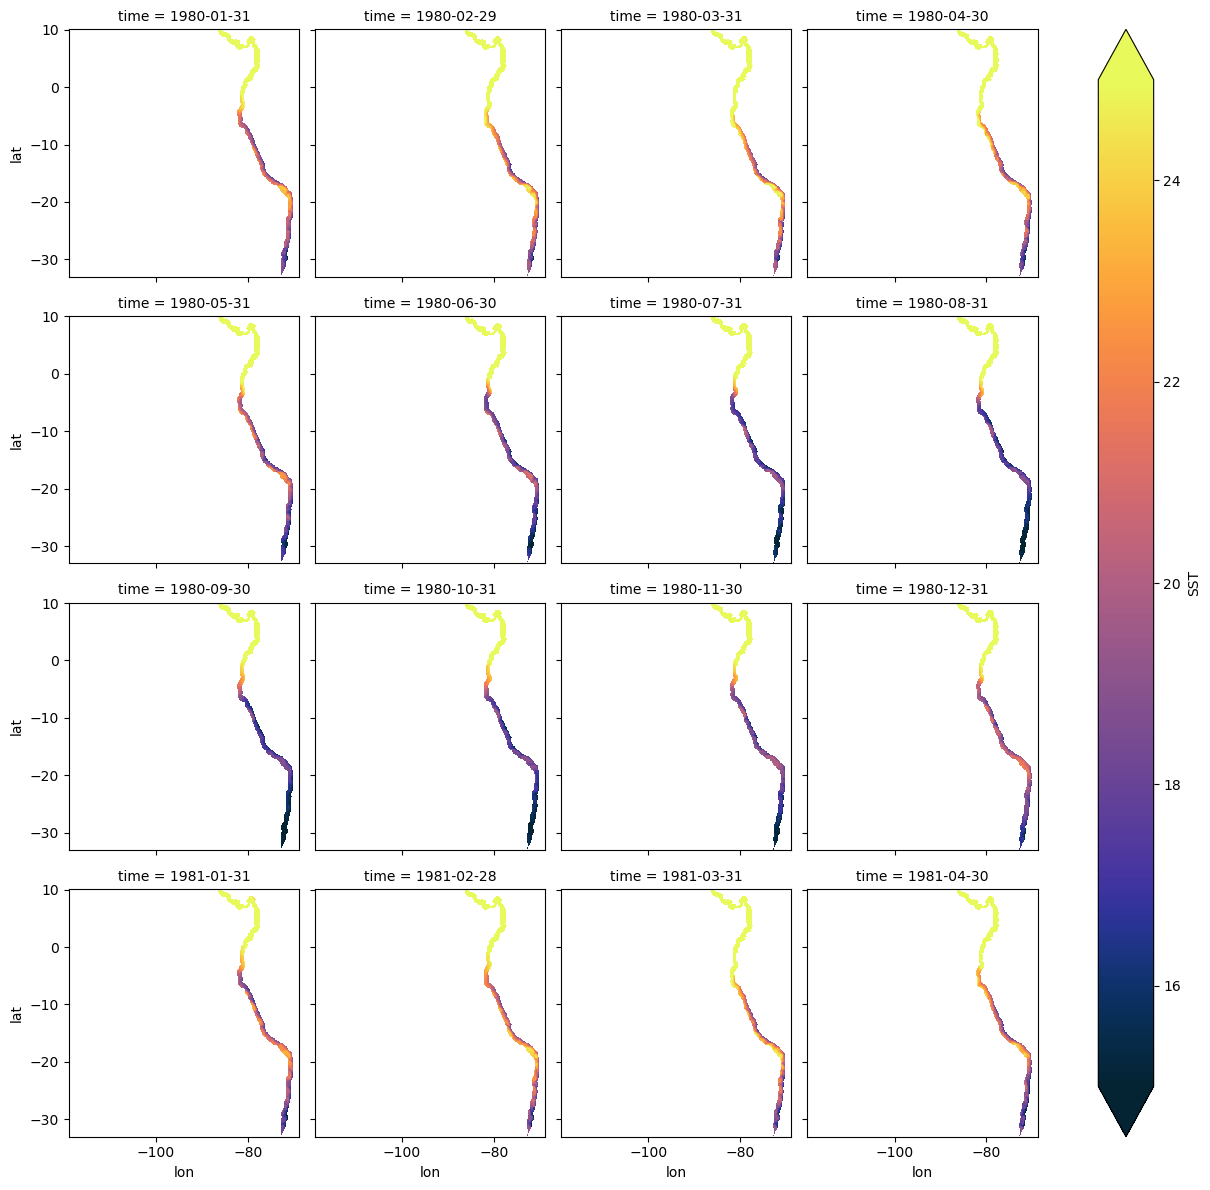

In [12]:
SST_inshore = ds_temp['SST'] * inshore_mask
SST_inshore.isel(time=slice(None,16)).plot(x="lon", y="lat", cmap=cm.thermal,
                                              col = 'time', col_wrap=4,
                                         vmin=15, vmax=25)

In [13]:
## Offshore 500km 
r5 = "../../NHCS/hindcast/CROCO_BioEBUS_1990-2010/indices/BK500km.kml"
r6 = "../../NHCS/hindcast/CROCO_BioEBUS_1990-2010/indices/BK600km.kml"

R5 = kml2struct(r5)
R6 = kml2struct(r6)

# Extract Lon and Lat from the first polygon
lonb5 = R5[0]["Lon"]
latb5 = R5[0]["Lat"]
lonb6 = R6[0]["Lon"]
latb6 = R6[0]["Lat"]

### cutting the 500km
polygon5 = Path(np.column_stack((lonb5, latb5)))
polygon6 = Path(np.column_stack((lonb6, latb6)))

# Check which points are inside the polygon
mask5 = polygon5.contains_points(lonlat_points).reshape(LON.shape)
mask6 = polygon6.contains_points(lonlat_points).reshape(LON.shape)

# Convert the mask to NaN for the outshore region
offshore_mask5 = np.where(mask5, 1, np.nan)
offshore_mask6 = np.where(mask6, 1, np.nan)

/tmp/ipykernel_2277849/4048778958.py:6: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  plt.colorbar(label="Space Between Masks")


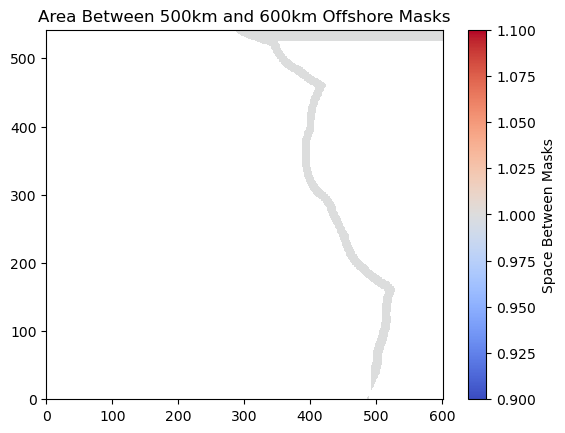

In [14]:
# Calculate the space between the two masks
space_between_masks = np.where((offshore_mask6 == 1) & (offshore_mask5 != 1), 1, np.nan)

# Plot the result
plt.pcolor(space_between_masks, cmap="coolwarm")
plt.colorbar(label="Space Between Masks")
plt.title("Area Between 500km and 600km Offshore Masks")
plt.show()

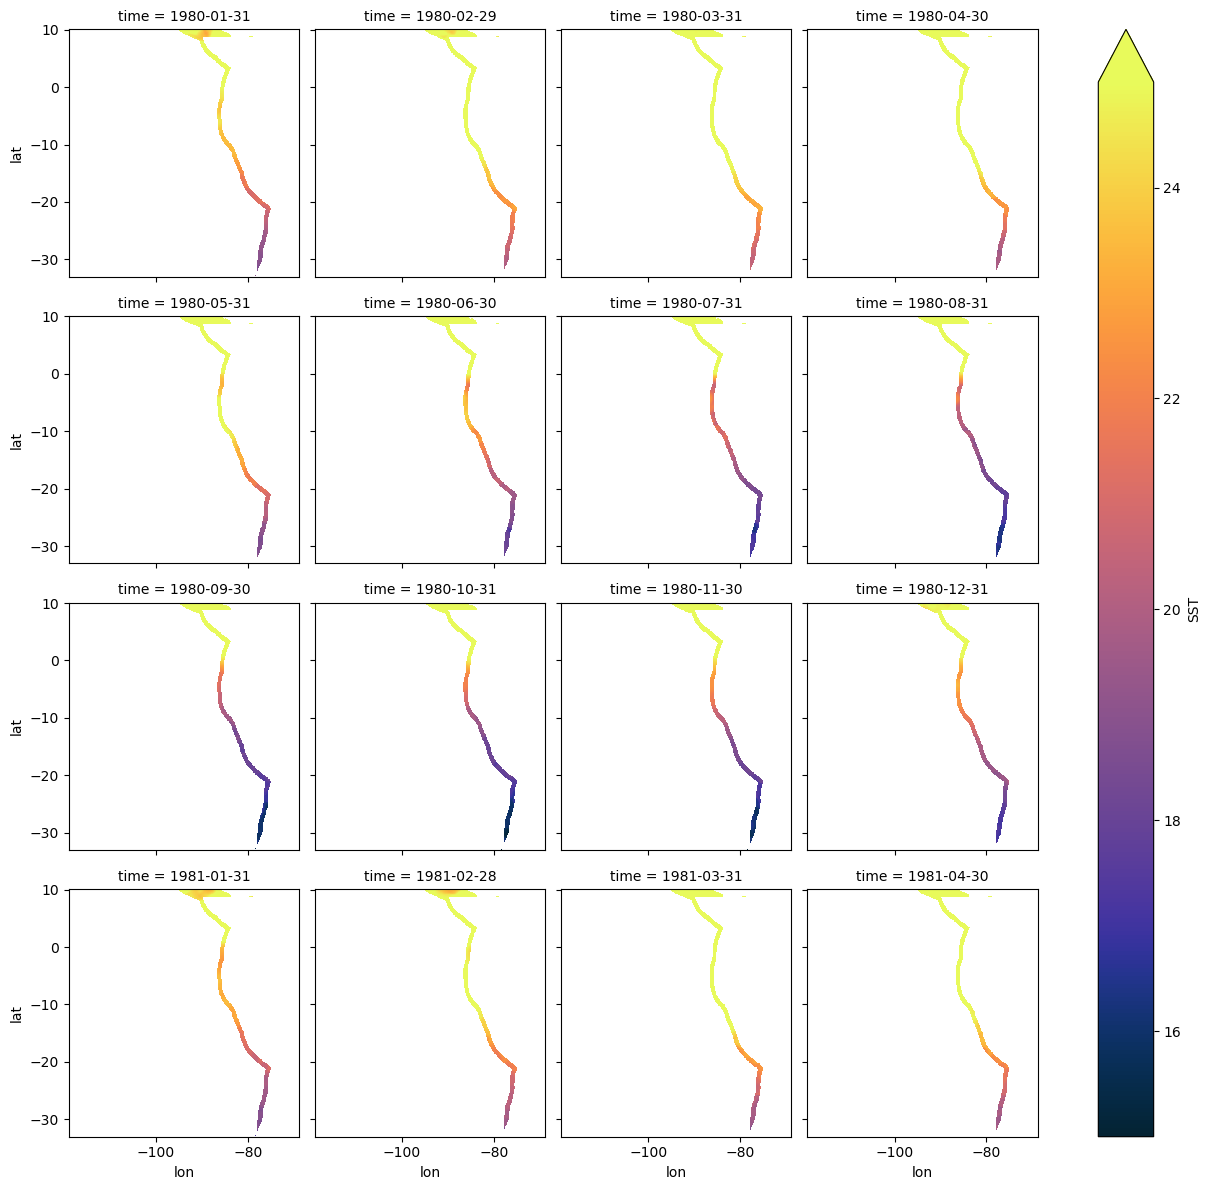

In [15]:
SST_offshore = ds_temp['SST'] * space_between_masks
# SST_offshore = SST['SST'] * offshore_mask5
SST_offshore.isel(time=slice(None,16)).plot(x="lon", y="lat", cmap=cm.thermal,
                                              col = 'time', col_wrap=4,
                                         vmin=15, vmax=25)

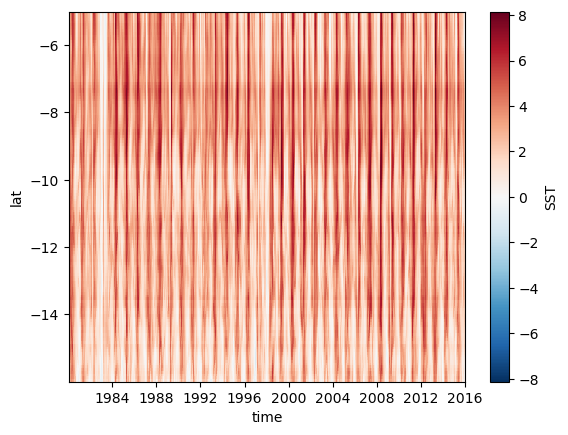

In [16]:
CUI_old = SST_offshore.mean(dim='lon') - SST_inshore.mean(dim='lon')
CUI_old.sel(lat=slice(-16,-5)).plot(x='time',y='lat')

In [17]:
def seasonality(data):
    
    season = data.groupby('time.month').mean(dim='time')
    return season

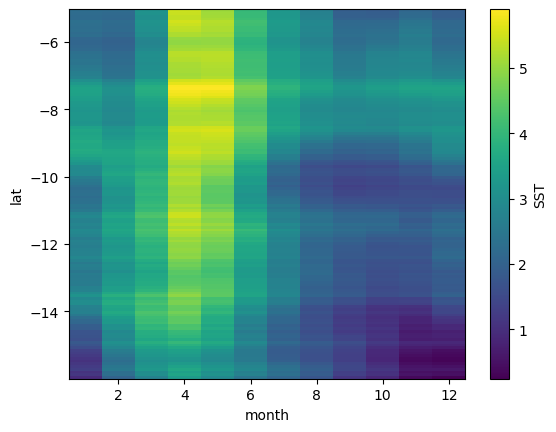

In [18]:
CUI_season = seasonality(CUI_old)
CUI_season.sel(lat=slice(-16,-5)).plot(x='month',y='lat')

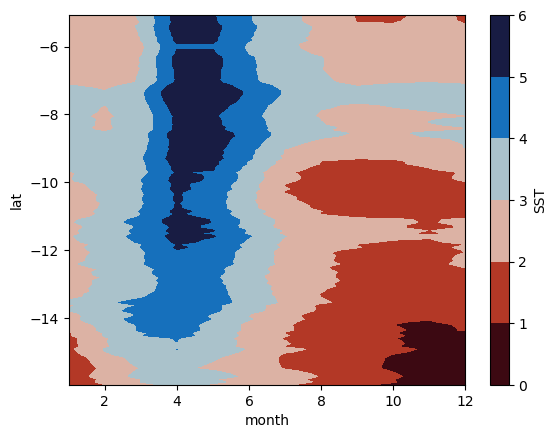

In [19]:
CUI_season.sel(lat=slice(-16,-5)).plot.contourf(x='month',y='lat',cmap=cm.balance_r)

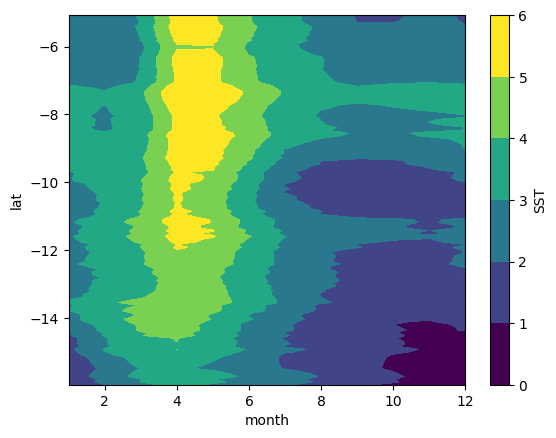

In [20]:
CUI_abs = abs(SST_offshore.mean(dim='lon') - SST_inshore.mean(dim='lon'))
CUI_abs_season = seasonality(CUI_abs)
CUI_abs_season.sel(lat=slice(-16,-5)).plot.contourf(x='month',y='lat')

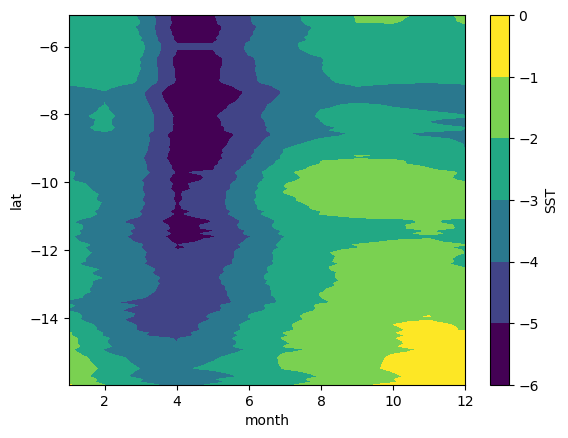

In [21]:
CUI_in = SST_inshore.mean(dim='lon') - SST_offshore.mean(dim='lon')
CUI_in_season = seasonality(CUI_in)
CUI_in_season.sel(lat=slice(-16,-5)).plot.contourf(x='month',y='lat')

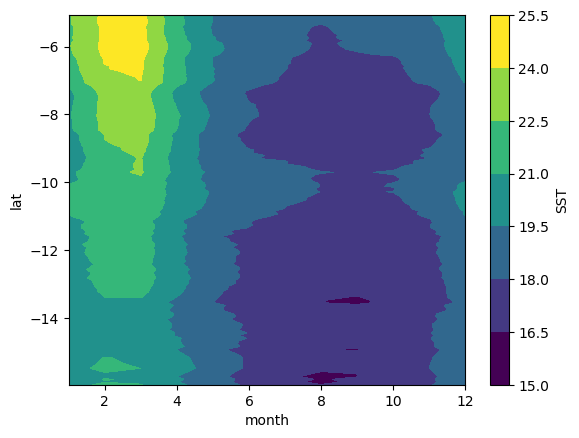

In [22]:
seasonality(SST_inshore.mean(dim='lon')).sel(lat=slice(-16,-5)).plot.contourf(x='month')
# seasonality(SST_offshore.mean(dim='lon')).sel(lat=slice(-16,-5)).plot.contourf(x='month')

/tmp/ipykernel_2277849/2689450419.py:59: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels, fontsize=12)
/tmp/ipykernel_2277849/2689450419.py:59: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels, fontsize=12)


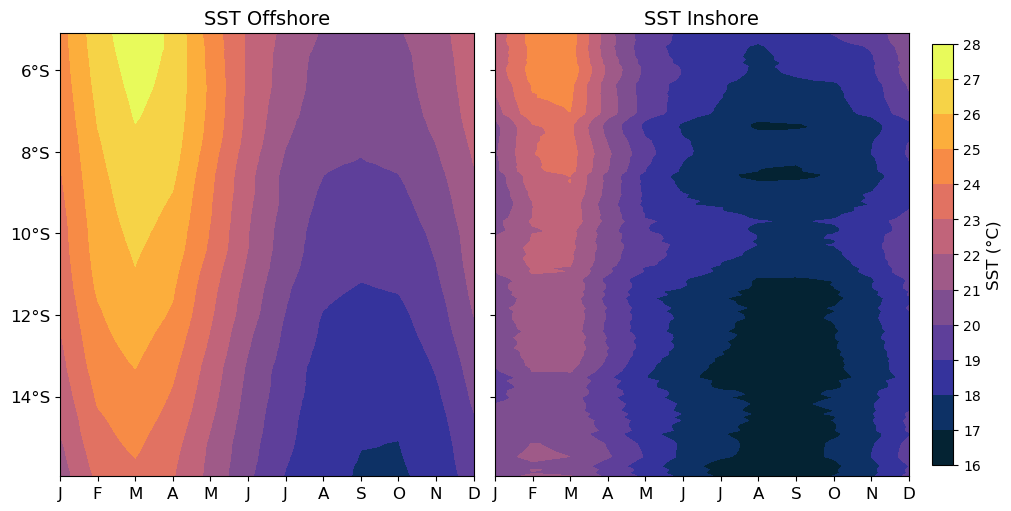

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from cmocean import cm

# Prepare data
SST_in = seasonality(SST_inshore.mean(dim='lon')).sel(lat=slice(-16, -5))
SST_off = seasonality(SST_offshore.mean(dim='lon')).sel(lat=slice(-16, -5))

# Use consistent levels from the combined range (absolute SST)
vmin = float(xr.concat([SST_in, SST_off], dim='stack').min().compute())
vmax = float(xr.concat([SST_in, SST_off], dim='stack').max().compute())
# Round to nice half-degrees
vmin = np.floor(vmin*2)/2
vmax = np.ceil(vmax*2)/2
levels = np.round(np.linspace(vmin, vmax, 13))

months = ['J','F','M','A','M','J','J','A','S','O','N','D']

fig, (ax2, ax1) = plt.subplots(
    nrows=1, ncols=2, figsize=(10, 5),
    sharex=True, sharey=True,
    constrained_layout=True
)

# Inshore (top)
cf1 = SST_in.plot.contourf(
    x='month', ax=ax1, levels=levels, cmap=cm.thermal,
    add_colorbar=False
)
ax1.set_title('SST Inshore', fontsize=14)
ax1.set_ylabel('')
ax1.set_xlabel('')
# Offshore (bottom)
cf2 = SST_off.plot.contourf(
    x='month', ax=ax2, levels=levels, cmap=cm.thermal,
    add_colorbar=False
)
ax2.set_title('SST Offshore', fontsize=14)
# ax2.set_xlabel('Month', fontsize=12)
ax2.set_ylabel('')
ax2.set_xlabel('')
# Month ticks
for ax in (ax1, ax2):
    ax.set_xticks(range(1, 13))
ax1.set_xticklabels(months, fontsize=12)  # hide on top
ax2.set_xticklabels(months, fontsize=12)

# Format latitude ticks as degrees S (since -16 to -5)
def lat_labels(ax):
    yt = ax.get_yticks()
    labels = []
    for y in yt:
        if y < 0:
            labels.append(f"{-y:.0f}°S")
        elif y > 0:
            labels.append(f"{y:.0f}°N")
        else:
            labels.append("0°")
    ax.set_yticklabels(labels, fontsize=12)

lat_labels(ax1)
lat_labels(ax2)

# One shared colorbar on the right
cbar = fig.colorbar(cf2, ax=[ax1, ax2], orientation='vertical', pad=0.02, shrink=0.95)
cbar.set_label('SST (°C)', fontsize=12)
cbar.set_ticks(levels)
cbar.ax.tick_params(labelsize=10)

# plt.savefig('Figures/paper/SST_inshore_offshore.png', dpi=300, bbox_inches='tight')
plt.show()

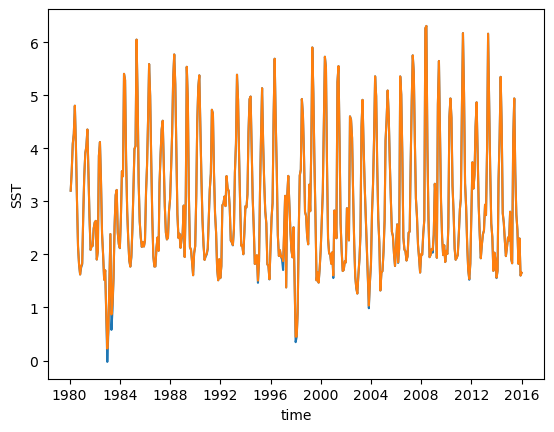

In [24]:
CUI_old.sel(lat=slice(-16,-5)).mean(dim='lat',skipna=True).plot()
CUI_abs.sel(lat=slice(-16,-5)).mean(dim='lat',skipna=True).plot()
# CUI_in.sel(lat=slice(-16,-5)).mean(dim='lat',skipna=True).plot()

## Salvatecci 2018

doi: 10.1111/gcb.13991Glob Change Biol. 2018;24:1055–1068. wileyonlinelibrary.com/journal/gcb © 2017 John Wiley & Sons Ltd | 1055

* Inshore: SST anomalies from the coastal area (12° to 17°S; 73° to 78°W). 
* Offshore: SST anomalies from theoffshore area (11 to 21°S; 80 to 90°W). 


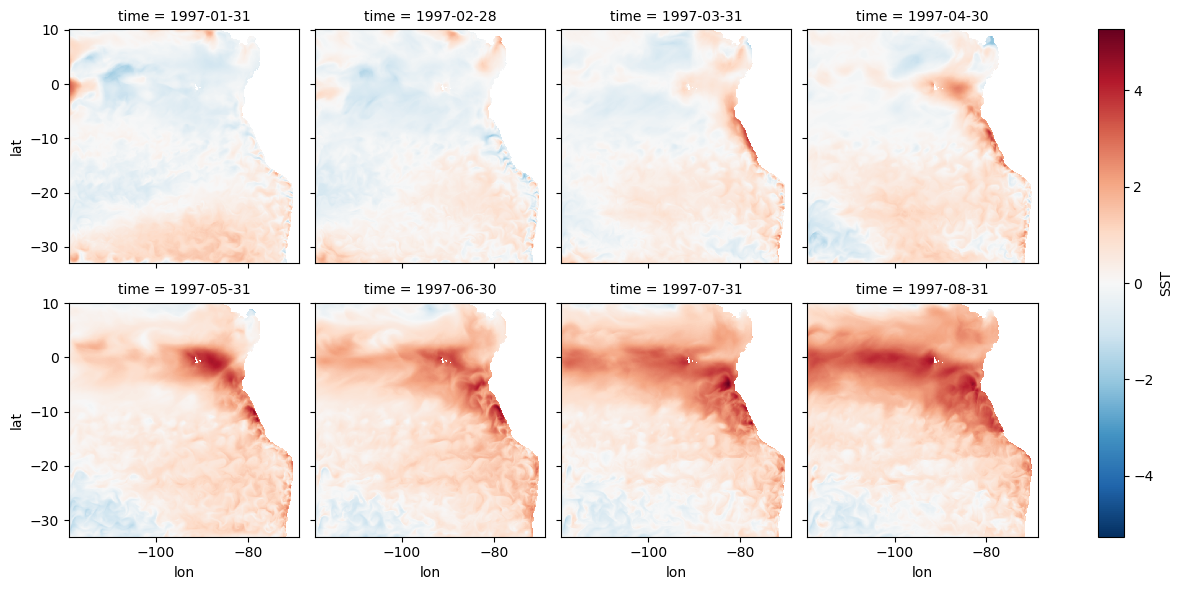

In [25]:
#Anomalies
SSTa = ds_temp.groupby("time.month") - seasonality(ds_temp)
SSTa.SST.sel(time=slice('1997-01','1997-08')).plot(col='time',col_wrap=4)

<xarray.Dataset> Size: 13MB
Dimensions:  (lon: 60, lat: 62, time: 432)
Coordinates:
  * lon      (lon) float64 480B -77.95 -77.87 -77.78 ... -73.2 -73.12 -73.03
  * lat      (lat) float64 496B -16.99 -16.91 -16.83 ... -12.24 -12.16 -12.07
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
    month    (time) int64 3kB 1 2 3 4 5 6 7 8 9 10 11 ... 3 4 5 6 7 8 9 10 11 12
Data variables:
    SST      (time, lat, lon) float64 13MB 0.3873 0.4002 0.4226 ... nan nan nan

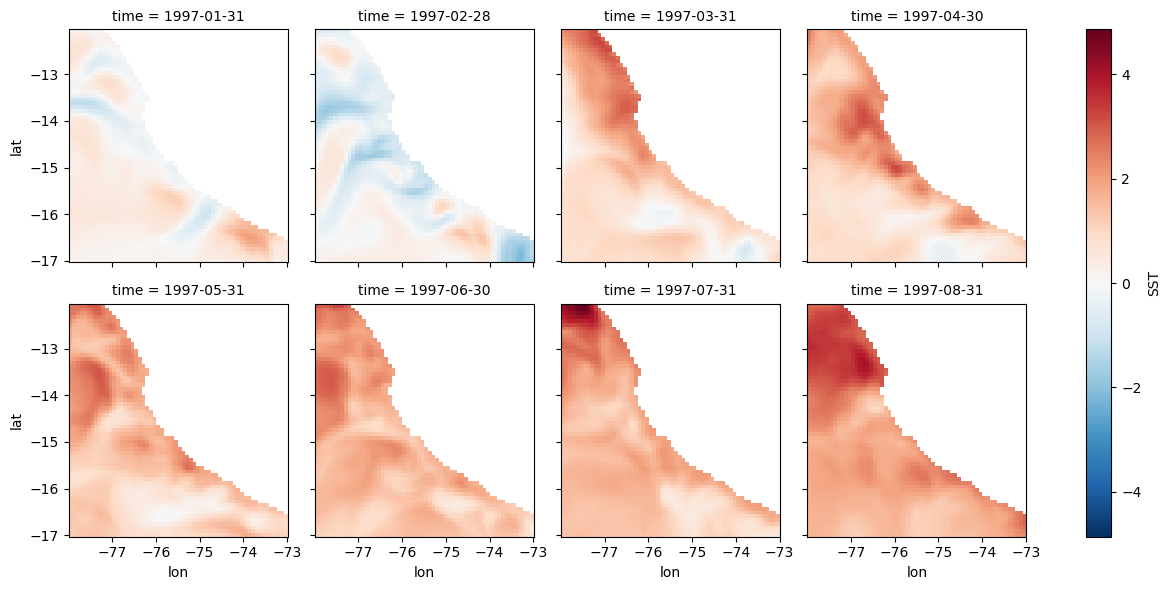

In [26]:
inshore = SSTa.sel(lat=slice(-17,-12),lon=slice(-78,-73))
inshore.sel(time=slice('1997-01','1997-08')).SST.plot(col='time',col_wrap=4)
inshore

<xarray.Dataset> Size: 52MB
Dimensions:  (lon: 120, lat: 125, time: 432)
Coordinates:
  * lon      (lon) float64 960B -89.95 -89.87 -89.78 ... -80.2 -80.12 -80.03
  * lat      (lat) float64 1kB -20.93 -20.85 -20.78 ... -11.18 -11.1 -11.01
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
    month    (time) int64 3kB 1 2 3 4 5 6 7 8 9 10 11 ... 3 4 5 6 7 8 9 10 11 12
Data variables:
    SST      (time, lat, lon) float64 52MB 0.03757 0.04056 ... 0.7938 0.7928

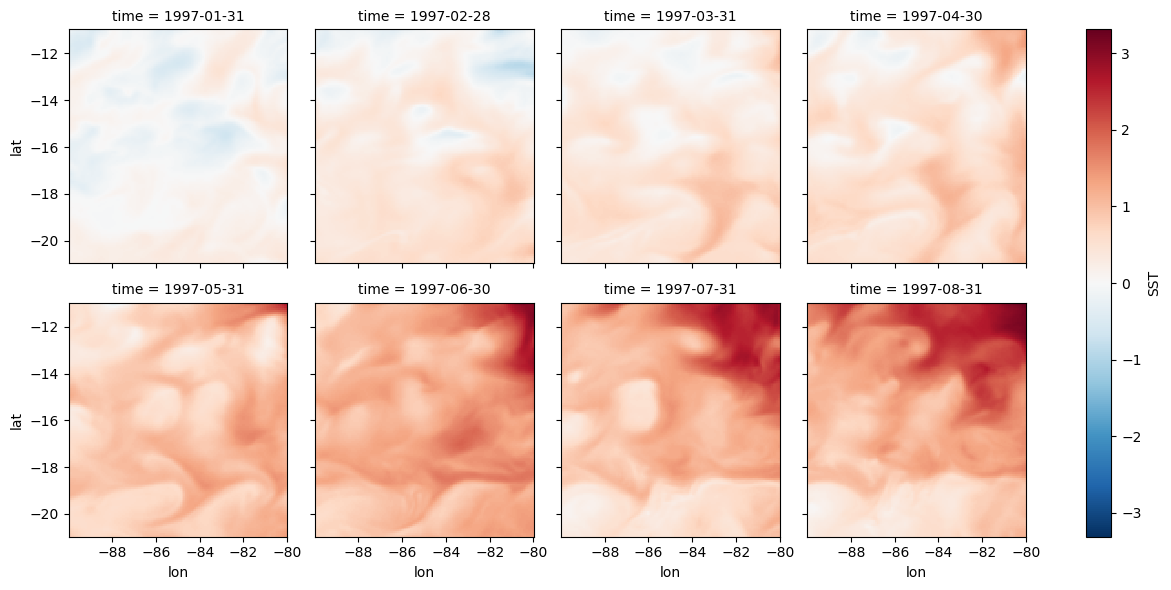

In [27]:
#Offshore: SST anomalies from theoffshore area (11 to 21°S; 80 to 90°W).
offshore= SSTa.sel(lat=slice(-21,-11),lon=slice(-90,-80))
offshore.SST.sel(time=slice('1997-01','1997-08')).plot(col='time',col_wrap=4)
offshore

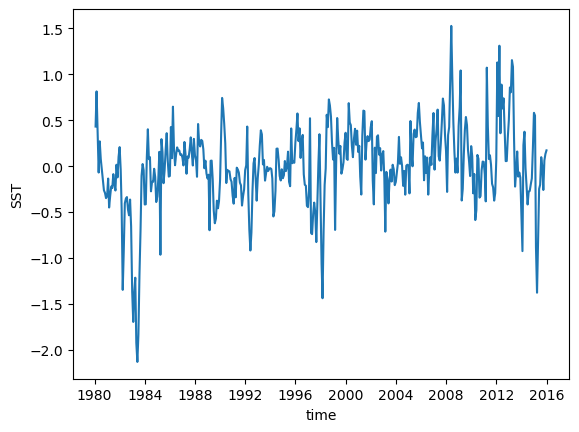

In [28]:
SST_ui = offshore.mean(dim={'lat','lon'},skipna=True) - inshore.mean(dim={'lat','lon'},skipna=True)
SST_ui.SST.plot()
# SST_ui.time=slice('1997-01','1997-08').SST.plot(col='time',col_wrap=4)
# offshore - inshore.time=slice('1997-01','1997-08').SST.plot(col='time',col_wrap=4)

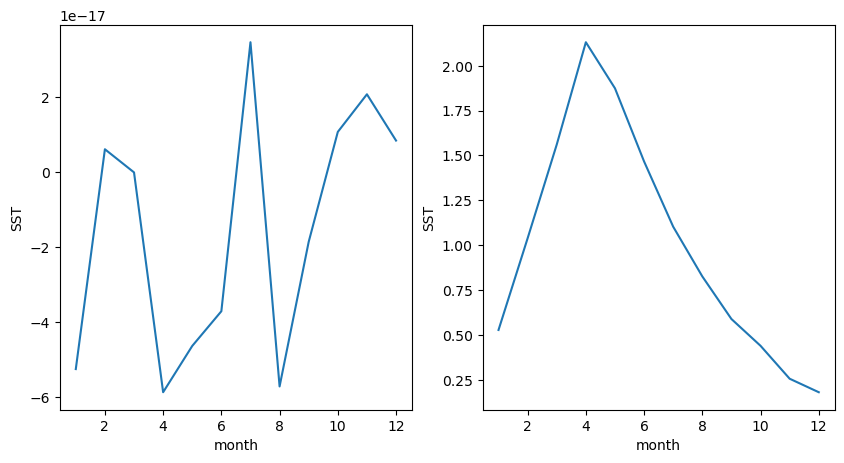

In [29]:
fig,ax= plt.subplots(1,2,figsize=(10,5))

seasonality(SST_ui).SST.plot(ax=ax[0])
CUI_season.mean(dim='lat').plot(ax=ax[1])


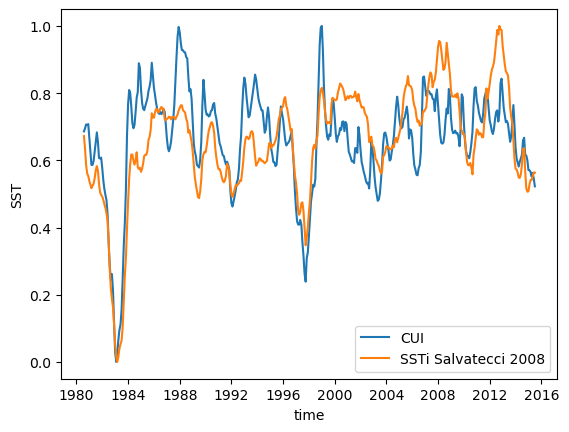

In [30]:
normalize(CUI_old.sel(lat=slice(-16,-5)).mean(dim='lat',skipna=True).rolling(time=13,center=True).mean()).plot(label='CUI')
normalize(SST_ui.SST.rolling(time=13,center=True).mean()).plot(label='SSTi Salvatecci 2008')
plt.legend()

## CHLOR

In [31]:
CHL = xr.open_dataset('../../NHCS/hincast_1980-2015/Chlorophyll.nc',
                            chunks = {'time':1})
# ds_chl = ds_chl.rename({'latitude':'lat','longitude':'lon'})
CHL

<xarray.Dataset> Size: 1GB
Dimensions:  (time: 432, lat: 542, lon: 602)
Coordinates:
    s_rho    float64 8B ...
  * time     (time) datetime64[ns] 3kB 1980-01-01 1980-02-01 ... 2015-12-01
  * lon      (lon) float64 5kB -119.0 -118.9 -118.8 ... -69.03 -68.95 -68.87
  * lat      (lat) float64 4kB -33.0 -32.93 -32.86 -32.79 ... 9.869 9.951 10.03
Data variables:
    chla     (time, lat, lon) float64 1GB dask.array<chunksize=(1, 542, 602), meta=np.ndarray>

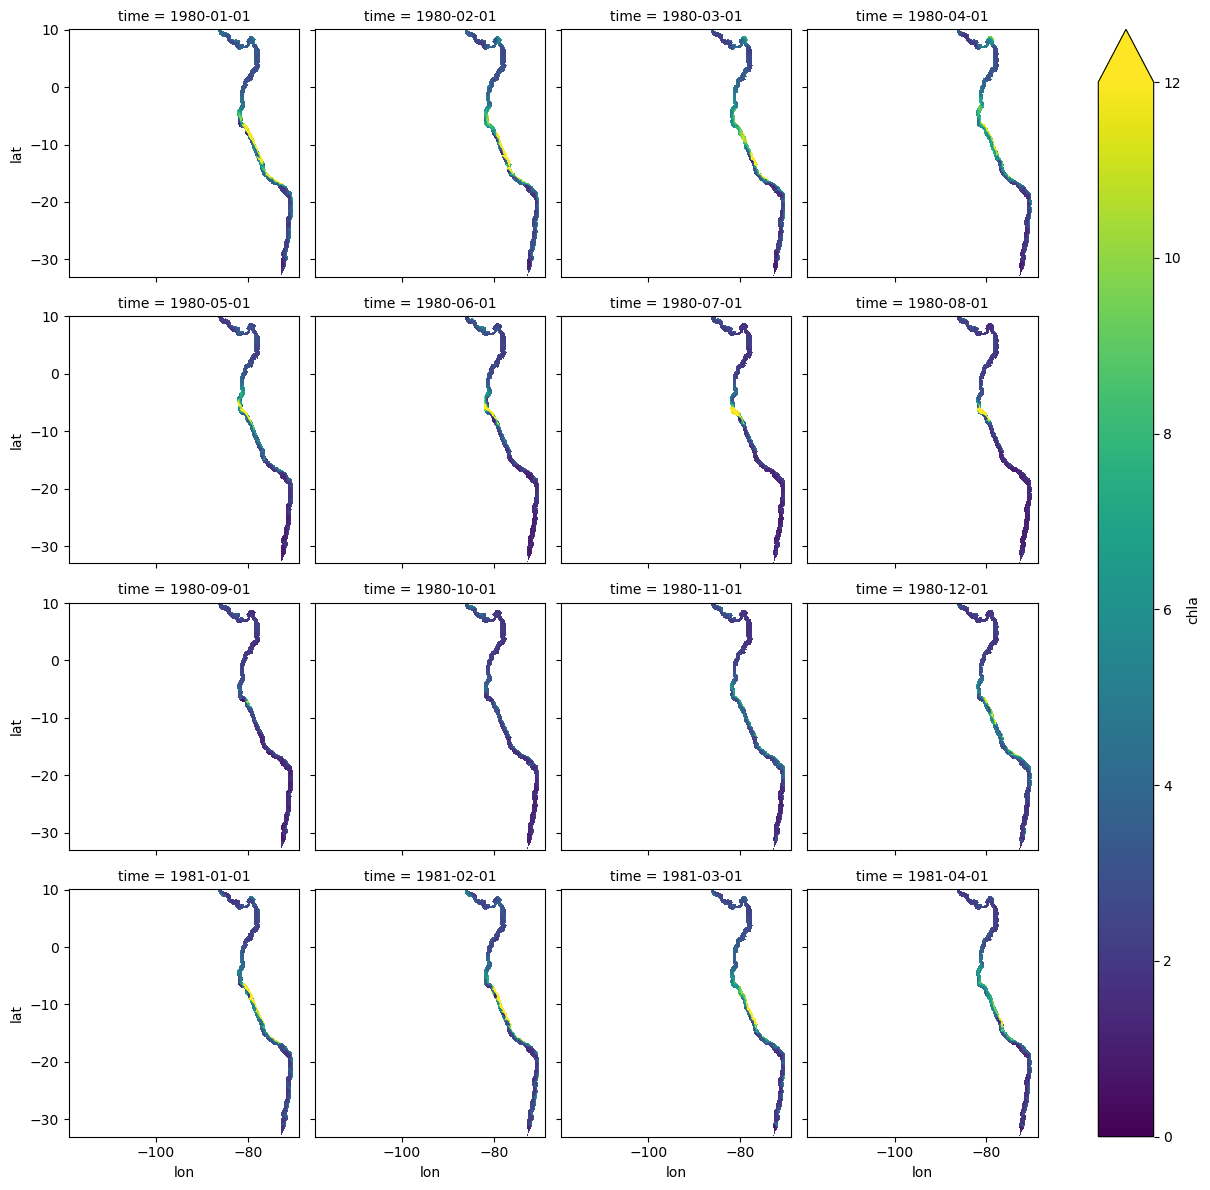

In [32]:
CHL.chla.isel(time=slice(None,16)).plot(x='lon',y='lat',
                                          col='time',col_wrap=4,vmin=0, vmax=12)


In [33]:
def seasonality(data):
    
    season = data.groupby('time.month').mean(dim='time')
    return season

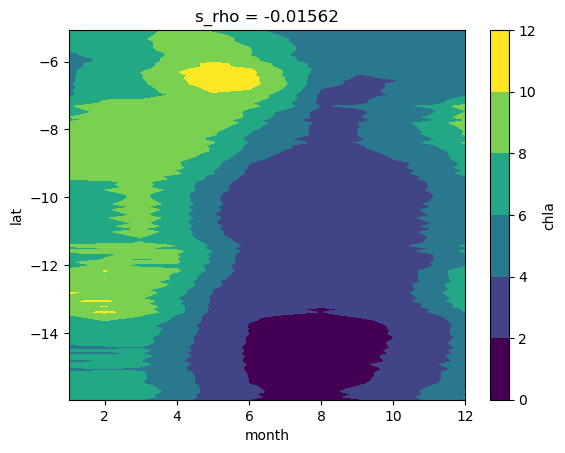

In [34]:
chl_season = seasonality(CHL)
chl_season.mean(dim='lon').chla.sel(lat=slice(-16,-5)).plot.contourf(x='month',y='lat')

## CROCO $W_{MLD}$ 

In [35]:
WMLD_data = loadmat("../../NHCS/Processed/WMLD_MLD.mat")
print(WMLD_data.keys())

WMLD_ds_ = xr.Dataset(
    data_vars={
        'WMLD': (("time", "lat","lon"), WMLD_data['WMLD'].transpose(2, 0, 1)),
    },
    coords = {
        'lon':ds.lon_rho.compute().values[0,:],
        'lat':ds.lat_rho.compute().values[:,0],
        'time':time
}
)

WMLD_ds_

dict_keys(['__header__', '__version__', '__globals__', 'MLD', 'WMLD'])


<xarray.Dataset> Size: 1GB
Dimensions:  (time: 432, lat: 542, lon: 602)
Coordinates:
  * lon      (lon) float64 5kB -119.0 -118.9 -118.8 ... -69.03 -68.95 -68.87
  * lat      (lat) float64 4kB -33.0 -32.93 -32.86 -32.79 ... 9.869 9.951 10.03
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
Data variables:
    WMLD     (time, lat, lon) float64 1GB 4.613e-08 4.613e-08 ... 0.0 0.0

In [36]:
mask_rho = ds.mask_rho.values 
mask_nan = np.where(mask_rho, 1, np.nan)

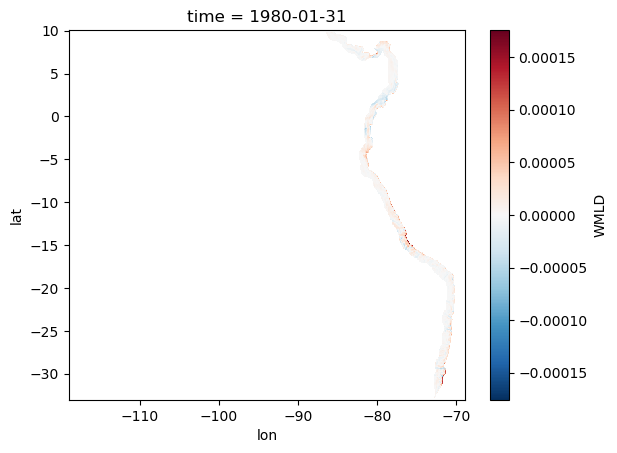

In [37]:
WMLD_ds_['WMLD'] = WMLD_ds_['WMLD'] * inshore_mask *mask_nan
WMLD_ds_.isel(time=0).WMLD.plot()

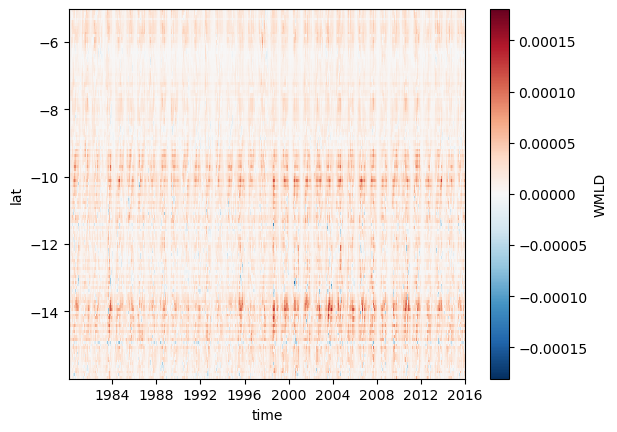

In [38]:
WMLD_ds_.WMLD.mean('lon').sel(lat=slice(-16,-5)).plot(x='time')

In [39]:
WMLD_mean=WMLD_ds_.WMLD.mean('lon',skipna=True)*86400
WMLD_mean

<xarray.DataArray 'WMLD' (time: 432, lat: 542)> Size: 2MB
array([[        nan,  4.35030896,  0.03127658, ..., -0.09380383,
                nan,         nan],
       [        nan,  2.98334104, -0.30545057, ...,  0.41559579,
                nan,         nan],
       [        nan,  1.43712225, -0.99493573, ..., -0.0321141 ,
                nan,         nan],
       ...,
       [        nan,  1.0500354 , -0.02352306, ..., -0.04496862,
                nan,         nan],
       [        nan, -0.13912238,  0.5472891 , ..., -0.39683479,
                nan,         nan],
       [        nan, -0.17255764,  0.10028733, ..., -0.4135188 ,
                nan,         nan]])
Coordinates:
  * lat      (lat) float64 4kB -33.0 -32.93 -32.86 -32.79 ... 9.869 9.951 10.03
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31

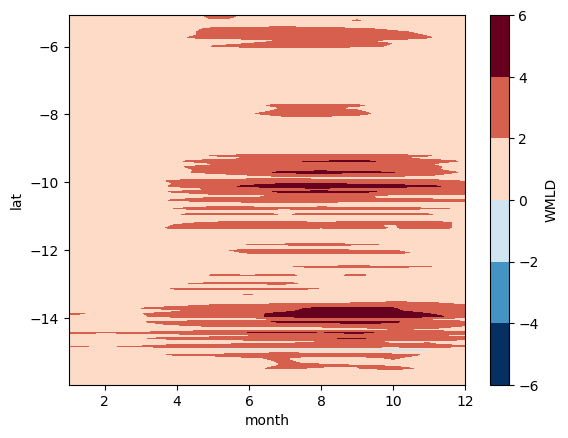

In [40]:
wmld_season = seasonality(WMLD_ds_*86400)
wmld_season.WMLD.mean(dim='lon',skipna=True).sel(lat=slice(-16,-5)).plot.contourf(x='month',y='lat')

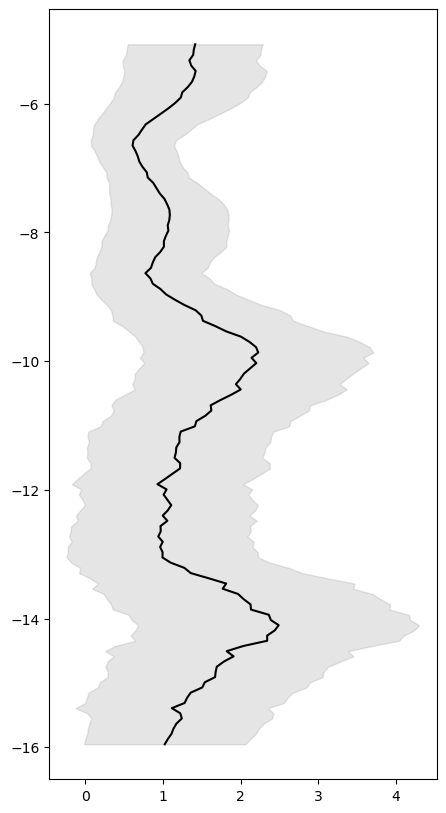

In [41]:
mean = WMLD_mean.mean(dim=('time')).rolling(lat=13, center=True).mean().sel(lat=slice(-16,-5))
std = WMLD_mean.std(dim='time').rolling(lat=13, center=True).mean().sel(lat=slice(-16,-5))
lat = WMLD_mean.sel(lat=slice(-16,-5)).lat.values

fig,ax= plt.subplots(1,1,figsize=(5,10))

plt.plot(mean, lat, color='black', linewidth=1.5)
    # Plot standard deviation band
plt.fill_betweenx(lat,
                    mean - std,
                    mean + std,
                    color='gray',
                    alpha=0.2,
                    label='±1 SD')

# wmld_season.WMLD.mean(dim=('lon','month'),skipna=True).sel(lat=slice(-16,-5)).plot()

In [42]:
wmld = wmld_season.WMLD.mean(dim='lon',skipna=True).sel(lat=slice(-16,-5))
wmld

<xarray.DataArray 'WMLD' (month: 12, lat: 134)> Size: 13kB
array([[0.41779647, 0.45488965, 0.78612464, ..., 0.63653185, 0.59616999,
        0.57915203],
       [0.53104738, 0.44445168, 0.75152794, ..., 0.3508197 , 0.26349673,
        0.26922087],
       [0.74419704, 0.60776008, 0.94439907, ..., 0.5392326 , 0.45212999,
        0.47102938],
       ...,
       [1.14580257, 0.43195601, 1.48199048, ..., 1.51877152, 1.43373816,
        1.40450232],
       [0.64693865, 0.76825107, 1.53288881, ..., 1.39016408, 1.34878439,
        1.38468425],
       [0.56919236, 0.49237908, 0.91831397, ..., 1.12863251, 1.00063096,
        0.92242787]])
Coordinates:
  * lat      (lat) float64 1kB -15.95 -15.87 -15.79 ... -5.242 -5.159 -5.076
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12

/tmp/ipykernel_2277849/3072581113.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(new_labels,fontsize=16)


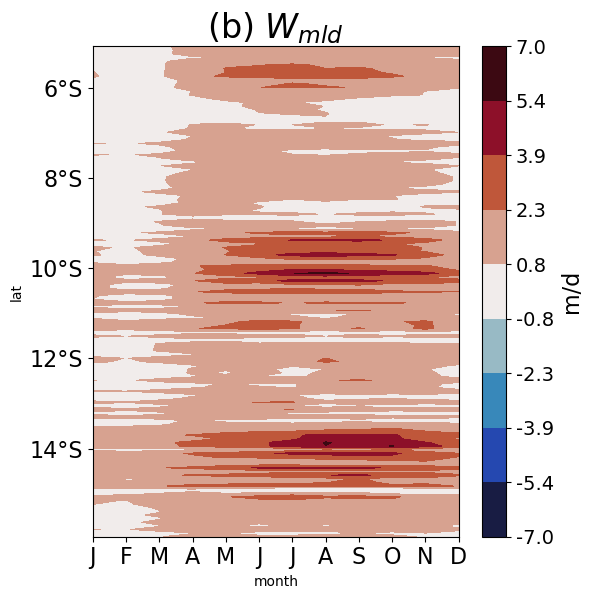

In [43]:
from matplotlib.colors import TwoSlopeNorm 
fig, ax = plt.subplots(figsize=(6,6))

# np.linspace(-5, 5, 10) 
vmin=-7; vmax=7
norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

levels=np.linspace(vmin,vmax,10)

cf=wmld.plot.contourf(x='month',vmin=vmin, vmax=vmax,cmap = cm.balance,
                                                                 norm=norm,levels=levels,add_colorbar=False)
ax = plt.gca()
cbar = plt.colorbar(cf, ax=ax)
cbar.set_label('m/d',fontsize=16)
cbar.ax.set_yticklabels([f"{tick:.1f}" for tick in levels], fontsize=14)  # 1 decimal formatting

yticks = ax.get_yticks()  # Get current y-tick positions

# Format labels with °S for negative values (Southern Hemisphere)
new_labels = [f"{-y:.0f}°S" if y < 0 else f"{y:.0f}°N" for y in yticks]
ax.set_yticklabels(new_labels,fontsize=16)

plt.title('(b) $W_{mld}$',fontsize=24)
plt.tight_layout()

months = ['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D']
plt.xticks(range(1, 13), months,fontsize=16)  # Assuming your data has 12 points (one per month)

# plt.savefig('Figures/wmld_season_poster'+'.png', format='png', dpi=300, transparent=False, bbox_inches='tight')
plt.show()

/tmp/ipykernel_2277849/1494747123.py:63: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_yticklabels(yticklabels, fontsize=12)
/tmp/ipykernel_2277849/1494747123.py:92: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_yticklabels(yticklabels2, fontsize=12)


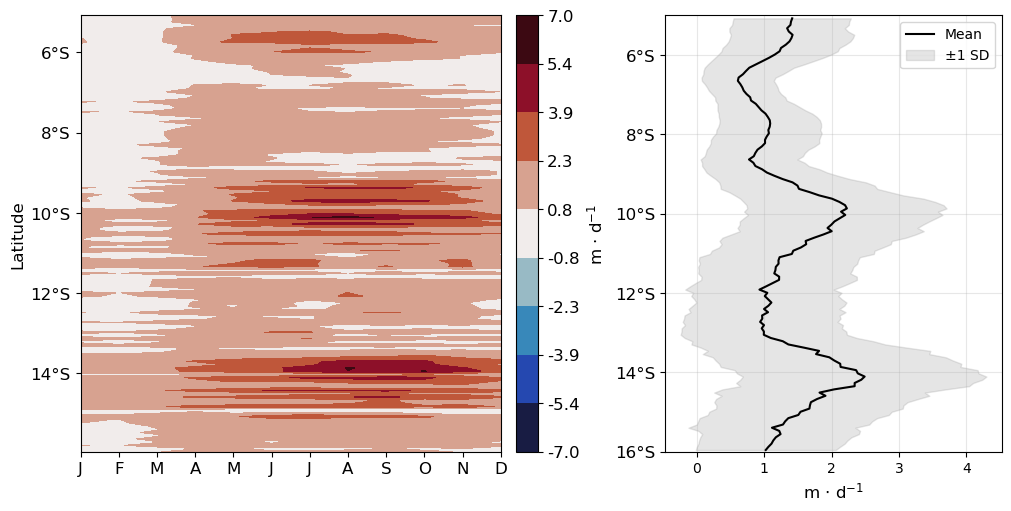

In [44]:
import matplotlib.pyplot as plt
import numpy as np
from cmocean import cm
from matplotlib.colors import TwoSlopeNorm

# -------------------------
# Prep for left panel (seasonal contour)
# -------------------------
vmin, vmax = -7, 7
levels = np.linspace(vmin, vmax, 10)
norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)
months = ['J','F','M','A','M','J','J','A','S','O','N','D']

# -------------------------
# Prep for right panel (mean ±1SD vs latitude)
# -------------------------
mean = WMLD_mean.mean(dim='time').rolling(lat=13, center=True).mean().sel(lat=slice(-16, -5))
std  = WMLD_mean.std(dim='time').rolling(lat=13, center=True).mean().sel(lat=slice(-16, -5))
lat  = WMLD_mean.sel(lat=slice(-16, -5)).lat

# -------------------------
# Figure and axes
# -------------------------
fig, (ax1, ax2) = plt.subplots(
    ncols=2, nrows=1,
    figsize=(10, 5),
    gridspec_kw={'width_ratios': [1.25, 1.0]},
    constrained_layout=True
)

# -------------------------
# Left panel: WMLD seasonal contour
# -------------------------
cf = wmld.plot.contourf(
    x='month',
    ax=ax1,
    vmin=vmin, vmax=vmax,
    cmap=cm.balance,
    norm=norm,
    levels=levels,
    add_colorbar=False
)

# Colorbar
cbar = fig.colorbar(cf, ax=ax1, orientation='vertical', pad=0.02)
cbar.set_label('m $\cdot$ d$^{-1}$', fontsize=12)
# Set ticks to match your levels and format to 1 decimal
cbar.set_ticks(levels)
cbar.set_ticklabels([f"{tick:.1f}" for tick in levels])
for t in cbar.ax.get_yticklabels():
    t.set_fontsize(12)

# Y tick formatting with °S/°N
yticks = ax1.get_yticks()
yticklabels = []
for y in yticks:
    if y < 0:
        yticklabels.append(f"{-y:.0f}°S")
    elif y > 0:
        yticklabels.append(f"{y:.0f}°N")
    else:
        yticklabels.append("0°")
ax1.set_yticklabels(yticklabels, fontsize=12)

# X ticks as months 1..12
ax1.set_xticks(range(1, 13))
ax1.set_xticklabels(months, fontsize=12)
ax1.set_xlabel('')
ax1.set_ylabel('Latitude', fontsize=12)
# ax1.set_title('(b) $W_{mld}$', fontsize=16)

# -------------------------
# Right panel: mean ±1 SD vs latitude
# -------------------------
ax2.plot(mean, lat, color='black', linewidth=1.5, label='Mean')
ax2.fill_betweenx(lat, mean - std, mean + std, color='gray', alpha=0.2, label='±1 SD')

# Niceties
ax2.set_xlabel('m $\cdot$ d$^{-1}$', fontsize=12)

ax2.set_ylim(-16,-5)
# Format y ticks like left panel
yticks2 = ax2.get_yticks()
yticklabels2 = []
for y in yticks2:
    if y < 0:
        yticklabels2.append(f"{-y:.0f}°S")
    elif y > 0:
        yticklabels2.append(f"{y:.0f}°N")
    else:
        yticklabels2.append("0°")
ax2.set_yticklabels(yticklabels2, fontsize=12)

ax2.grid(True, alpha=0.3)
ax2.legend(loc='best', fontsize=10)

# Optional: match y-limits across panels if they share the same lat range
# ax2.set_ylim(ax1.get_ylim())

# Save/show
# plt.savefig('Figures/paper/wmld_season_and_profile_x.png', dpi=300, bbox_inches='tight')
plt.show()

In [45]:
mean_WMLD = WMLD_ds_.WMLD.sel(lat=slice(-16, -5), lon=slice(-84, -73.5)).mean(dim='time',skipna=True)
mean_WMLD = xr.where(mean_WMLD == 0, np.nan, mean_WMLD)

lat = mean_WMLD.lat.values
lon = mean_WMLD.lon.values
loni, lati = np.meshgrid(lon, lat)

In [46]:
# import cartopy as ccrs

# # Create figure with two subplots
# fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(18*1.1, 6*1.1), 
#                               gridspec_kw={'width_ratios': [1.5, 1]},
#                               subplot_kw={'projection': ccrs.PlateCarree()})

# # First subplot (map)
# # --------------------------------------------------------------------------
# # Set up levels and normalization
# levels = np.linspace(-5, 5, 10)
# vmin, vmax = levels.min(), levels.max()
# norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

# # Plot the data using contourf
# cs = ax1.contourf(loni, lati, mean_WMLD*86400, cmap=cm.balance, norm=norm, 
#                  extend='both', levels=levels)

# # Add port labels
# for key in Puertos:
#     x, y = Puertos[key][1], Puertos[key][0]
#     ax1.text(x, y, key, fontsize=16)

# # Add colorbar
# cbar1 = plt.colorbar(cs, ax=ax1, orientation='vertical', pad=0.02, fraction=0.1)
# cbar1.set_label('m/d', fontsize=16)
# cbar1.set_ticklabels([f"{tick:.1f}" for tick in levels], fontsize=18)

# # # Add map features
# # land = cfeature.NaturalEarthFeature(
# #     category='physical',
# #     name='land',
# #     scale='10m',
# #     facecolor='lightgray',
# #     edgecolor=None
# # )
# # ax1.add_feature(land, alpha=1)
# # ax1.add_feature(cfeature.LAND, edgecolor='grey')
# ax1.set_title('(a) $W_{mld}$', fontsize=24)

# # Configure gridlines
# gl = ax1.gridlines(draw_labels=True, linestyle='--', alpha=0.1)
# gl.top_labels = False
# gl.right_labels = False
# gl.xlabel_style = {'size': 20}
# gl.ylabel_style = {'size': 20}

# # Set map extent
# ax1.set_extent([-84, -73.5, -16, -5])
# ax1.plot(lonb1, latb1, color='black', linewidth=3)

# # Second subplot (seasonal cycle)
# # --------------------------------------------------------------------------
# # Set up levels and normalization
# vmin, vmax = -7, 7
# norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)
# levels = np.linspace(vmin, vmax, 10)

# # Plot the seasonal cycle
# cf = wmld.plot.contourf(ax=ax2, x='month', vmin=vmin, vmax=vmax, 
#                           cmap=cm.balance, norm=norm, levels=levels, 
#                           add_colorbar=False)

# # Add colorbar
# cbar2 = plt.colorbar(cf, ax=ax2)
# cbar2.set_label('m/d', fontsize=16)
# cbar2.ax.set_yticklabels([f"{tick:.1f}" for tick in levels], fontsize=18)

# # Format y-axis labels
# yticks = ax2.get_yticks()
# new_labels = [f"{-y:.0f}°S" if y < 0 else f"{y:.0f}°N" for y in yticks]
# ax2.set_yticks(yticks)
# ax2.set_yticklabels(new_labels, fontsize=20)
# ax2.set_ylabel('Latitude',fontsize=16)
# ax2.set_ylim(-16,-5)

# # Configure x-axis
# months = ['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D']
# ax2.set_xticks(range(1, 13))
# ax2.set_xticklabels(months, fontsize=20)
# ax2.set_title('(b) $W_{mld}$', fontsize=24)

# # Adjust layout
# plt.tight_layout()

# # Save or show
# # plt.savefig('Figures/paper/combined_WMLD_plots_GOOD.png', format='png', dpi=300, transparent=False, bbox_inches='tight')
# plt.show()

## Nitrogen

In [47]:
nitro = loadmat("../../NHCS/Processed/Nitrogen.mat")
print(nitro.keys())

dict_keys(['__header__', '__version__', '__globals__', 'TN_MLD', 'TN_Surf'])


In [48]:
ds_nitro = xr.Dataset(
    data_vars={
        'Nitro_mld':(("time", "lat","lon"), nitro['TN_MLD'].transpose(2, 1, 0)*expanded_mask),
        'Nitro_surf':(("time", "lat","lon"), nitro['TN_Surf'].transpose(2, 1, 0)*expanded_mask),
    },
    coords = {
        'lon':ds.lon_rho.compute().values[0,:],
        'lat':ds.lat_rho.compute().values[:,0],
        'time':time
}
)
ds_nitro

<xarray.Dataset> Size: 2GB
Dimensions:     (time: 432, lat: 542, lon: 602)
Coordinates:
  * lon         (lon) float64 5kB -119.0 -118.9 -118.8 ... -69.03 -68.95 -68.87
  * lat         (lat) float64 4kB -33.0 -32.93 -32.86 ... 9.869 9.951 10.03
  * time        (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
Data variables:
    Nitro_mld   (time, lat, lon) float64 1GB 0.1585 0.1588 0.1642 ... nan nan
    Nitro_surf  (time, lat, lon) float64 1GB 0.1585 0.1588 0.1642 ... nan nan

In [49]:
ds_nitro = ds_nitro * inshore_mask

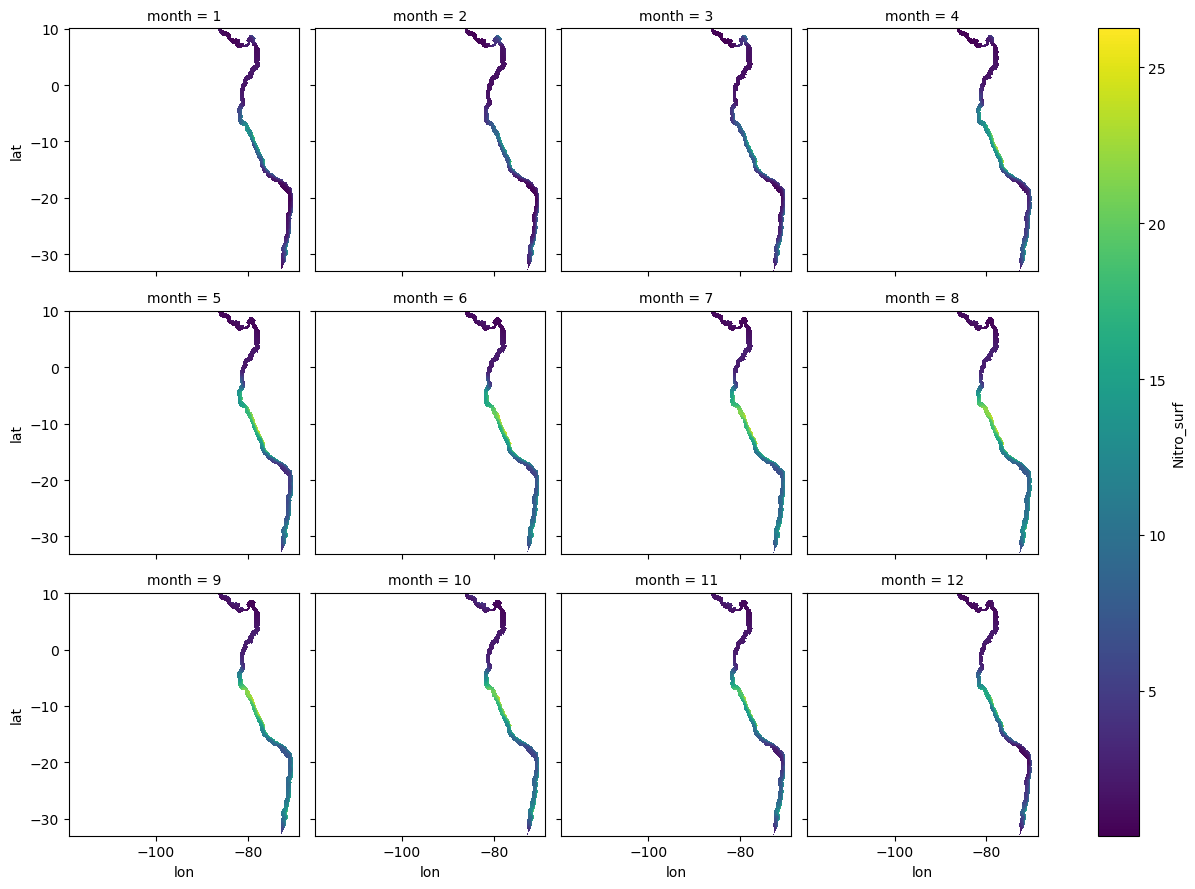

In [50]:
N_season = seasonality(ds_nitro)
N_season.Nitro_surf.plot(col='month',col_wrap=4)

Text(0.5, 1.0, '$N_{Surf - mld}$')

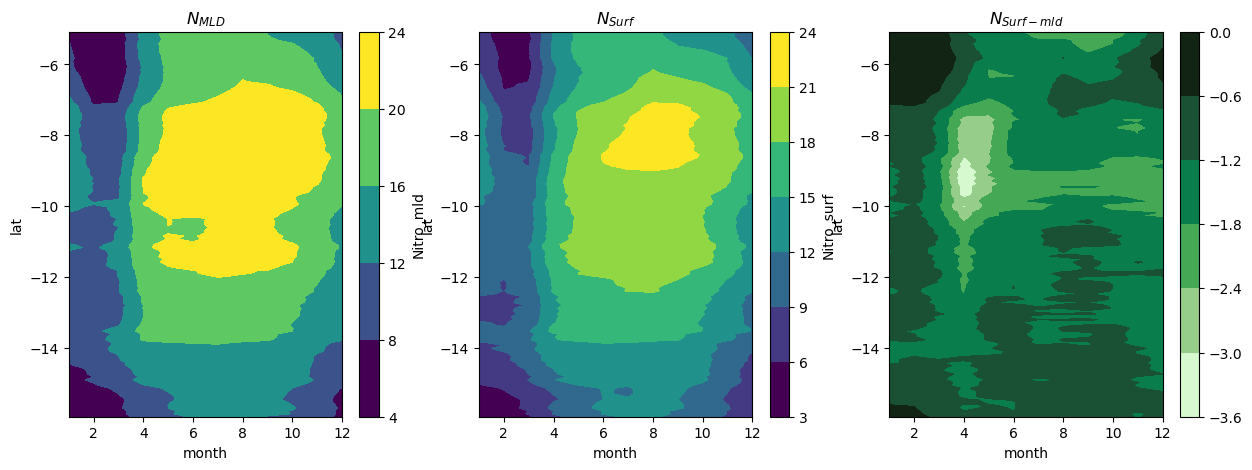

In [51]:
Ndiff_season = N_season.Nitro_surf - N_season.Nitro_mld
fig,ax =  plt.subplots(1, 3, figsize=(15, 5), sharex=True)
N_season.Nitro_mld.mean(dim='lon',skipna=True).sel(lat=slice(-16,-5)).plot.contourf(x='month',y='lat',ax=ax[0])
ax[0].set_title('$N_{MLD}$')
N_season.Nitro_surf.mean(dim='lon',skipna=True).sel(lat=slice(-16,-5)).plot.contourf(x='month',y='lat',ax=ax[1])
ax[1].set_title('$N_{Surf}$')
Ndiff_season.mean(dim='lon',skipna=True).sel(lat=slice(-16,-5)).plot.contourf(x='month',y='lat',cmap=cm.algae,ax=ax[2])
ax[2].set_title('$N_{Surf - mld}$')

In [52]:
N_ts = ds_nitro.groupby('time.month') - N_season
N_ts['Ndiff'] = N_ts.Nitro_surf - N_ts.Nitro_mld

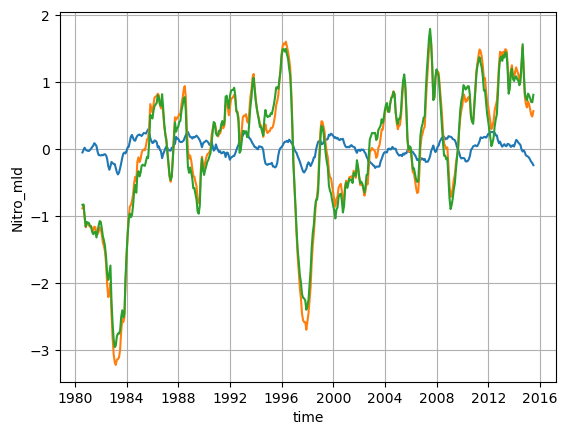

In [53]:
N_ts.Ndiff.sel(lat=slice(-16,-5)).mean(dim=('lat','lon'),skipna=True).rolling(time=13,center=True).mean().plot()
N_ts.Nitro_surf.sel(lat=slice(-16,-5)).mean(dim=('lat','lon'),skipna=True).rolling(time=13,center=True).mean().plot()
N_ts.Nitro_mld.sel(lat=slice(-16,-5)).mean(dim=('lat','lon'),skipna=True).rolling(time=13,center=True).mean().plot()
plt.grid()

In [54]:
def monthly_anomaly(da, dim=('lat','lon')):
    """
    Compute monthly climatological anomalies from a DataArray.
    
    Parameters:
    - da: xarray.DataArray with dimensions including 'time' and the spatial dim to average over
    - dim: spatial dimension to average over (e.g., 'lat')
    
    Returns:
    - anomaly: xarray.DataArray with monthly anomalies (same time dimension as input)
    """
    # Step 1: mean over the spatial dimension
    da_mean = da.mean(dim=dim, skipna=True)
    
    # Step 2: compute monthly climatology (climatological mean per month)
    monthly_clim = da_mean.groupby('time.month').mean(dim='time')
    
    # Step 3: subtract climatology to get anomaly
    anomaly = da_mean.groupby('time.month') - monthly_clim

    return anomaly

In [55]:
CHL['time'] = pd.date_range(start="1980-01",end="2016-01",freq='M')
CHL

/tmp/ipykernel_2277849/1318543881.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  CHL['time'] = pd.date_range(start="1980-01",end="2016-01",freq='M')


<xarray.Dataset> Size: 1GB
Dimensions:  (time: 432, lat: 542, lon: 602)
Coordinates:
    s_rho    float64 8B ...
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
  * lon      (lon) float64 5kB -119.0 -118.9 -118.8 ... -69.03 -68.95 -68.87
  * lat      (lat) float64 4kB -33.0 -32.93 -32.86 -32.79 ... 9.869 9.951 10.03
Data variables:
    chla     (time, lat, lon) float64 1GB dask.array<chunksize=(1, 542, 602), meta=np.ndarray>

In [56]:
monthly_anomaly(CHL.chla.sel(lat=slice(-16,-5)))

<xarray.DataArray 'chla' (time: 432)> Size: 3kB
dask.array<sub, shape=(432,), dtype=float64, chunksize=(1,), chunktype=numpy.ndarray>
Coordinates:
    s_rho    (time) float64 3kB -0.01562 -0.01562 -0.01562 ... -0.01562 -0.01562
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
    month    (time) int64 3kB 1 2 3 4 5 6 7 8 9 10 11 ... 3 4 5 6 7 8 9 10 11 12

Text(0.5, 1.0, 'N vs Chl')

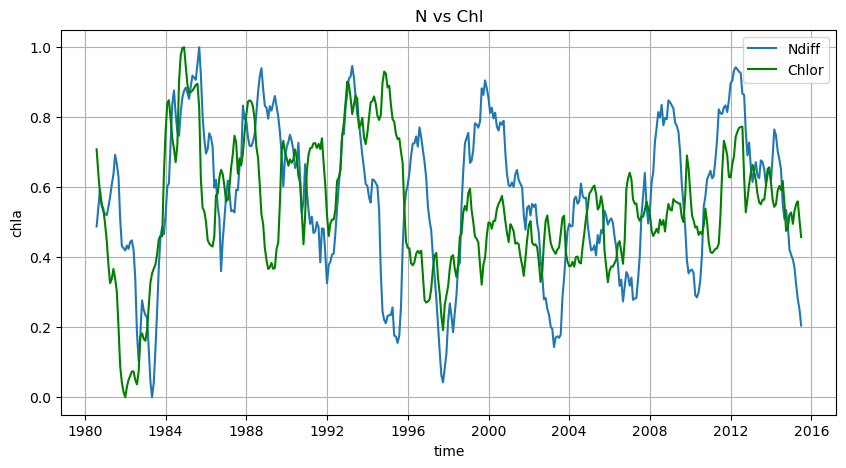

In [57]:
normalize(N_ts.Ndiff.sel(
    lat=slice(-16,-5)).mean(dim=('lat','lon'),skipna=True).rolling(time=13,center=True).mean()
         ).plot(label='Ndiff',figsize=(10,5))

normalize(monthly_anomaly(CHL.chla.sel(lat=slice(-16,-5))).rolling(time=13,center=True).mean()
         ).plot(label='Chlor',color='green')

plt.legend()
plt.grid()
plt.title('N vs Chl')

In [58]:
# Convertir a series y mantener el índice temporal
N = N_ts.Ndiff.sel(lat=slice(-16,-5)).mean(dim=('lat','lon'),skipna=True).rolling(time=13,center=True).mean()
Chlor = monthly_anomaly(CHL.chla.sel(lat=slice(-16,-5))).rolling(time=13,center=True).mean()


Ndiff_pd = N.to_series().dropna()
Chlor_pd = Chlor.to_series().dropna()

# Unir por índice (tiempo)
df = pd.concat([Ndiff_pd, Chlor_pd], axis=1)
df.columns = ['Ndiff', 'Chlor']
df

,Ndiff,Chlor
time,,
1980-07-31,-0.052431,0.424036
1980-08-31,-0.015613,0.245752
1980-09-30,0.018320,0.100002
1980-10-31,-0.011828,0.018717
1980-11-30,-0.023993,-0.011532
...,...,...
2015-02-28,-0.130854,-0.029671
2015-03-31,-0.164387,0.022649
2015-04-30,-0.193076,0.043958


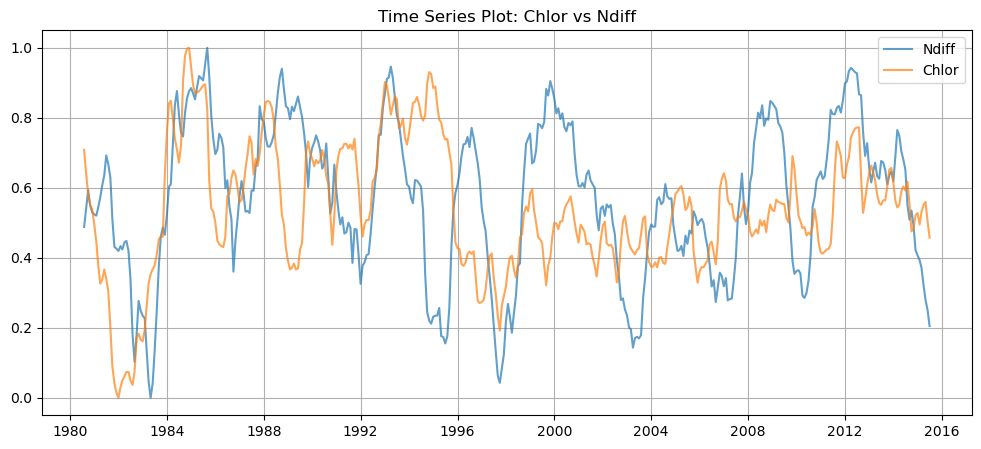


Top 3 cross-correlation peaks:
r = 0.389  |  lag = 5
r = 0.388  |  lag = 6
r = 0.388  |  lag = 4


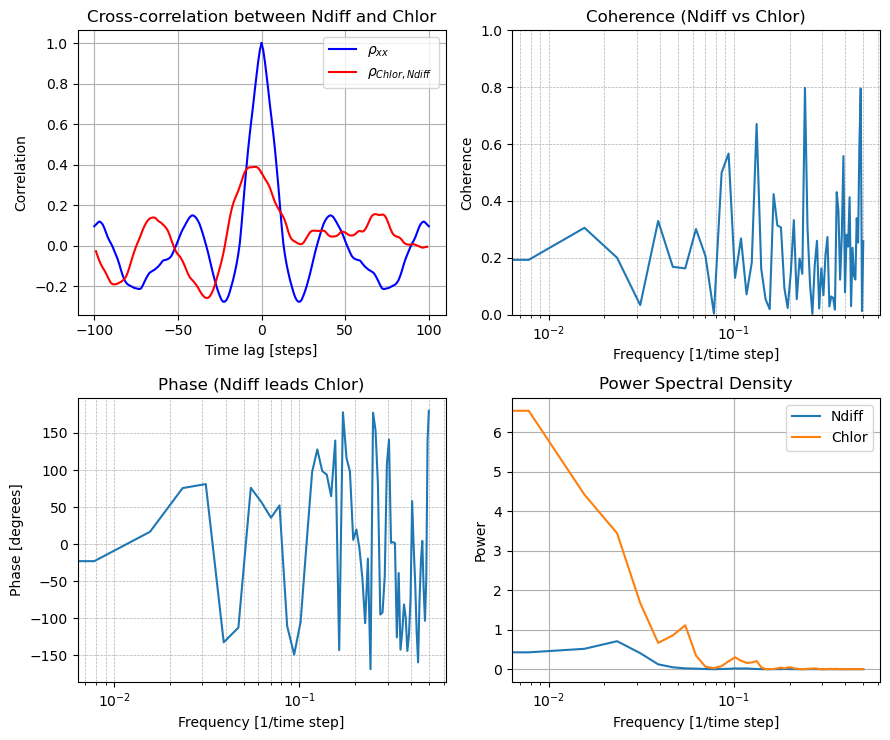

In [59]:
nperseg = 128
analyze_correlation_and_spectrum(df, 'Ndiff', 'Chlor',lags=100, nperseg=nperseg, xlim=500)

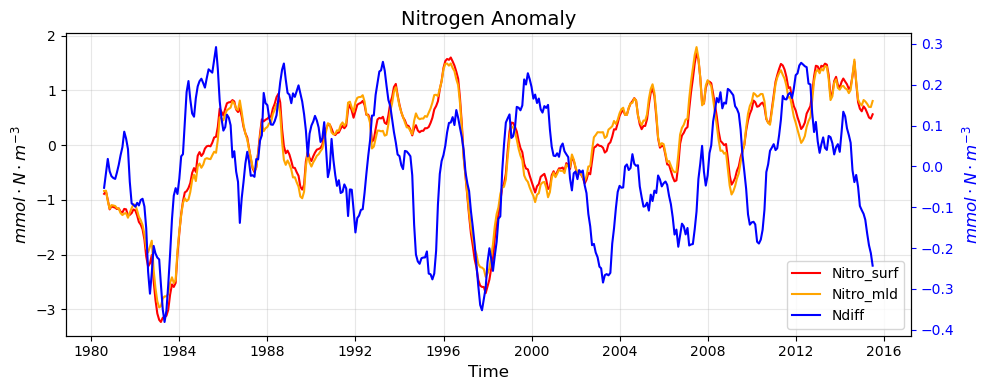

In [60]:
# import matplotlib.pyplot as plt

# Create figure and primary axis
fig, ax1 = plt.subplots(figsize=(10, 4))

# Plot Nitro_surf and Nitro_mld on primary axis (left)
N_ts.Nitro_surf.sel(lat=slice(-16,-5)).mean(dim=('lat','lon'), skipna=True)\
    .rolling(time=13, center=True).mean().plot(ax=ax1, color='red', label='Nitro_surf')
N_ts.Nitro_mld.sel(lat=slice(-16,-5)).mean(dim=('lat','lon'), skipna=True)\
    .rolling(time=13, center=True).mean().plot(ax=ax1, color='orange', label='Nitro_mld')

# Create secondary axis (right)
ax2 = ax1.twinx()

# Plot Ndiff on secondary axis (right)
N_ts.Ndiff.sel(lat=slice(-16,-5)).mean(dim=('lat','lon'), skipna=True)\
    .rolling(time=13, center=True).mean().plot(ax=ax2, color='blue', label='Ndiff')

# Customize the plot
ax1.set_xlabel('Time', fontsize=12)
ax1.set_ylabel('$mmol \cdot N \cdot m^{-3}$', fontsize=12, color='black')
ax2.set_ylabel('$mmol \cdot N \cdot m^{-3}$', fontsize=12, color='blue')

# Set colors for y-axis labels to match line colors
# ax1.tick_params(axis='y', colors='blue')
ax2.tick_params(axis='y', colors='blue')

# Add legend - combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower right')

# Add grid
ax1.grid(True, alpha=0.3)

plt.title('Nitrogen Anomaly', fontsize=14)
plt.tight_layout()
plt.show()



## Seasonality structure

/tmp/ipykernel_2277849/3249054082.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  a.set_yticklabels(new_labels, fontsize=12)
/tmp/ipykernel_2277849/3249054082.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  a.set_yticklabels(new_labels, fontsize=12)
/tmp/ipykernel_2277849/3249054082.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  a.set_yticklabels(new_labels, fontsize=12)


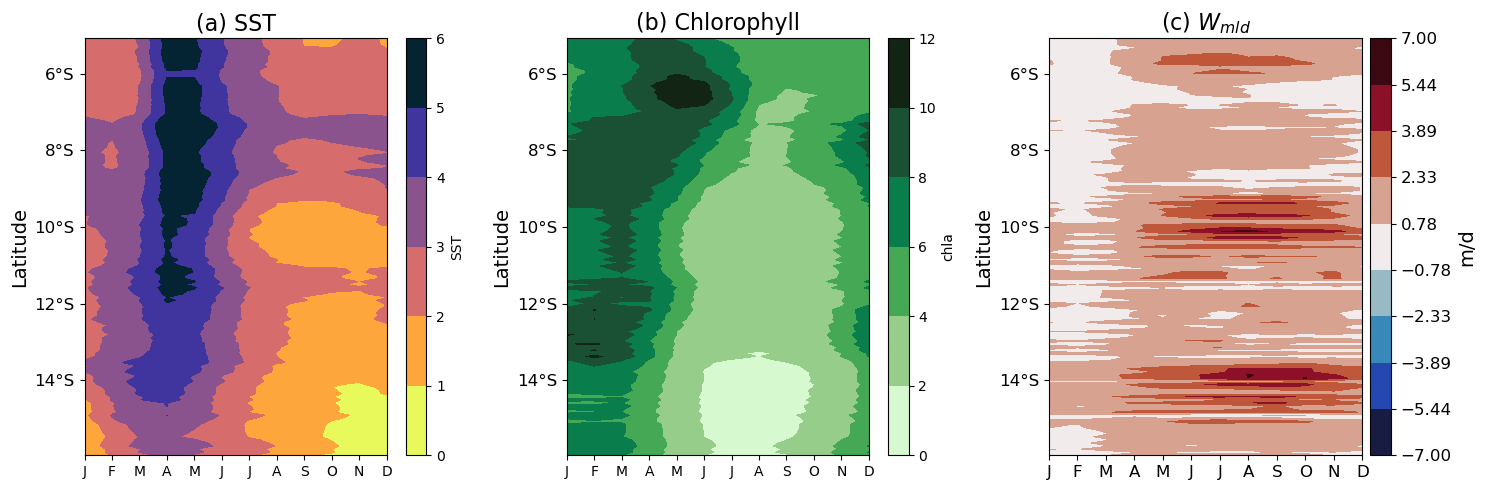

In [61]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import TwoSlopeNorm
from cmocean import cm # Make sure you have cmocean installed

# Create figure with 3 subplots
fig, ax = plt.subplots(1, 3, figsize=(15, 5), sharex=True)
plt.subplots_adjust(hspace=0.3)  # Adjust vertical spacing

# --- Plot 1: SST ---
CUI_season.sel(lat=slice(-16, -5)).plot.contourf(
    x='month', y='lat', cmap=cm.thermal_r, ax=ax[0], add_colorbar=True)
ax[0].set_title('(a) SST', fontsize=16)
ax[0].set_ylabel('Latitude', fontsize=14)

# --- Plot 2: Chlorophyll ---
chl_season.chla.sel(lat=slice(-16,-5)).mean(dim='lon',skipna=True).plot.contourf(
    x='month', y='lat', cmap=cm.algae, ax=ax[1], add_colorbar=True)
ax[1].set_title('(b) Chlorophyll', fontsize=16)
ax[1].set_ylabel('Latitude', fontsize=14)

# --- Plot 3: Wmld ---
vmin, vmax = -7, 7
norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)
levels = np.linspace(vmin, vmax, 10)

cf = wmld.plot.contourf(
    x='month', y='lat',
    cmap=cm.balance,
    norm=norm,
    levels=levels,
    add_colorbar=False,
    ax=ax[2]
)
ax[2].set_title('(c) $W_{mld}$', fontsize=16)
ax[2].set_ylabel('Latitude', fontsize=14)

# Add common colorbar for Wmld
cbar = fig.colorbar(cf, ax=ax[2], orientation='vertical', pad=0.02)
cbar.set_label('m/d', fontsize=14)
cbar.ax.tick_params(labelsize=12)

# Format y-axis labels for all subplots
for a in ax:
    yticks = a.get_yticks()
    new_labels = [f"{-y:.0f}°S" if y < 0 else f"{y:.0f}°N" for y in yticks]
    a.set_yticklabels(new_labels, fontsize=12)
    a.set_xlabel('')  # Remove x-label from upper plots

# Set common x-axis properties
months = ['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D']
ax[2].set_xticks(range(1, 13))
ax[2].set_xticklabels(months, fontsize=12)
# ax[2].set_xlabel('Month', fontsize=14)

plt.tight_layout()
# plt.savefig('Figures/combined_plot.png', dpi=300, bbox_inches='tight')
plt.show()

/tmp/ipykernel_2277849/3206751827.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  a.set_yticklabels(new_labels, fontsize=12)
/tmp/ipykernel_2277849/3206751827.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  a.set_yticklabels(new_labels, fontsize=12)
/tmp/ipykernel_2277849/3206751827.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  a.set_yticklabels(new_labels, fontsize=12)


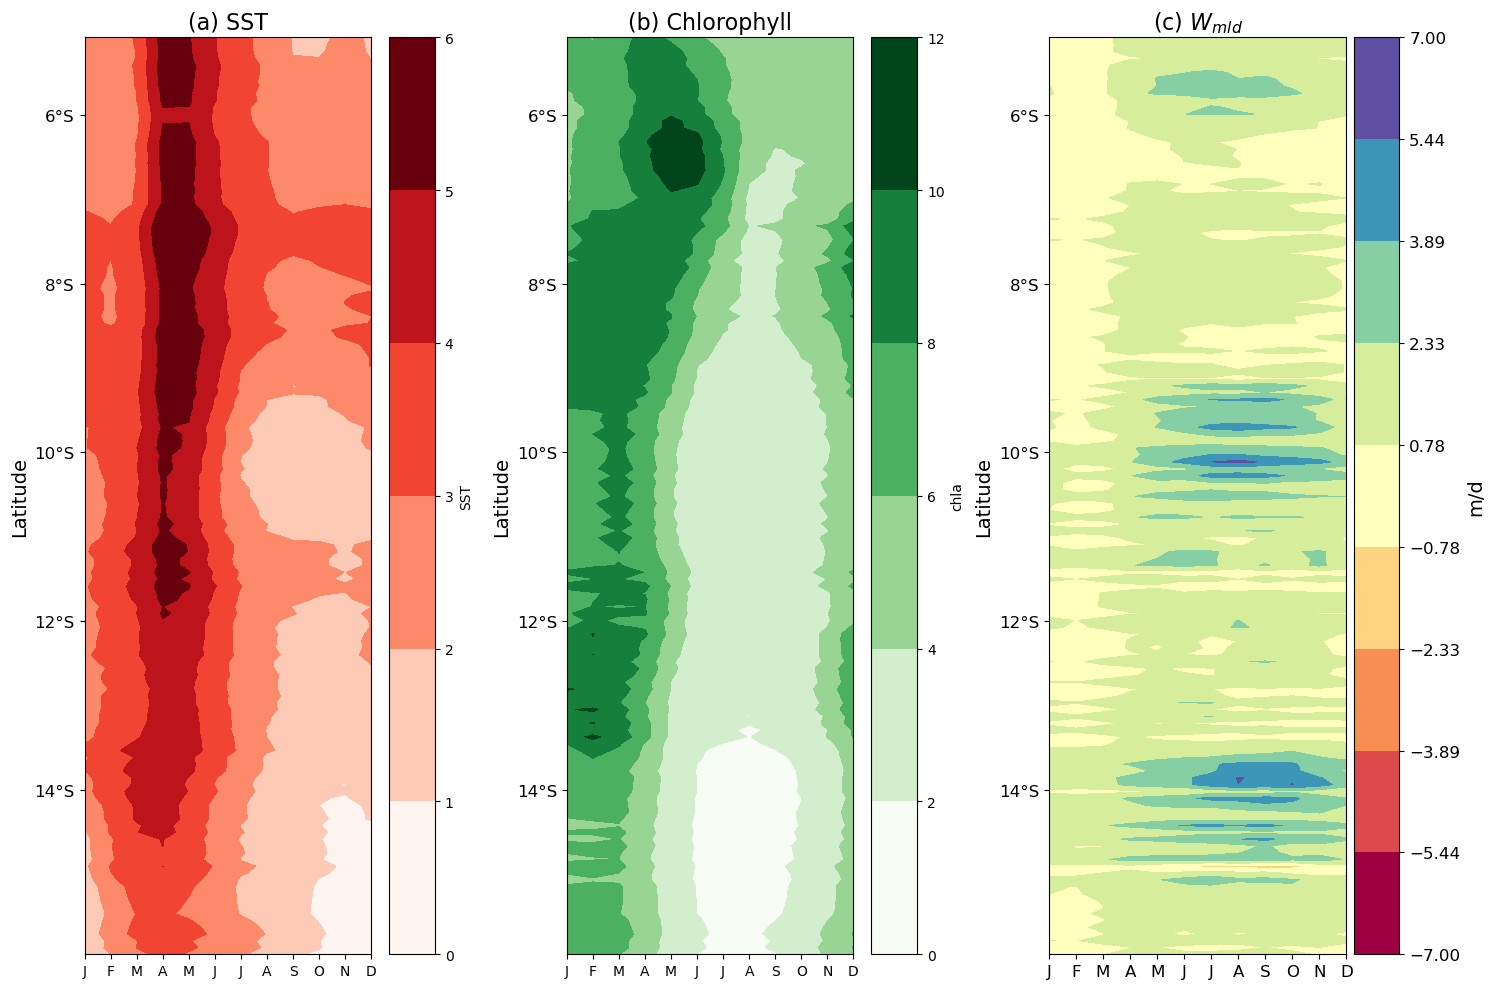

In [62]:
# Create figure with 3 subplots
fig, ax = plt.subplots(1, 3, figsize=(15, 10), sharex=True)
plt.subplots_adjust(hspace=0.3)  # Adjust vertical spacing

# --- Plot 1: SST ---
CUI_season.sel(lat=slice(-16, -5)).plot.contourf(
    x='month', y='lat', cmap='Reds', ax=ax[0], add_colorbar=True)
ax[0].set_title('(a) SST', fontsize=16)
ax[0].set_ylabel('Latitude', fontsize=14)

# --- Plot 2: Chlorophyll ---
chl_season.chla.sel(lat=slice(-16,-5)).mean(dim='lon',skipna=True).plot.contourf(
    x='month', y='lat', cmap='Greens', ax=ax[1], add_colorbar=True)
ax[1].set_title('(b) Chlorophyll', fontsize=16)
ax[1].set_ylabel('Latitude', fontsize=14)

# --- Plot 3: Wmld ---
vmin, vmax = -7, 7
norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)
levels = np.linspace(vmin, vmax, 10)

cf = wmld.plot.contourf(
    x='month', y='lat',
    cmap='Spectral',
    norm=norm,
    levels=levels,
    add_colorbar=False,
    ax=ax[2]
)
ax[2].set_title('(c) $W_{mld}$', fontsize=16)
ax[2].set_ylabel('Latitude', fontsize=14)

# Add common colorbar for Wmld
cbar = fig.colorbar(cf, ax=ax[2], orientation='vertical', pad=0.02)
cbar.set_label('m/d', fontsize=14)
cbar.ax.tick_params(labelsize=12)

# Format y-axis labels for all subplots
for a in ax:
    yticks = a.get_yticks()
    new_labels = [f"{-y:.0f}°S" if y < 0 else f"{y:.0f}°N" for y in yticks]
    a.set_yticklabels(new_labels, fontsize=12)
    a.set_xlabel('')  # Remove x-label from upper plots

# Set common x-axis properties
months = ['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D']
ax[2].set_xticks(range(1, 13))
ax[2].set_xticklabels(months, fontsize=12)
# ax[2].set_xlabel('Month', fontsize=14)

plt.tight_layout()
# plt.savefig('Figures/combined_plot.png', dpi=300, bbox_inches='tight')
plt.show()

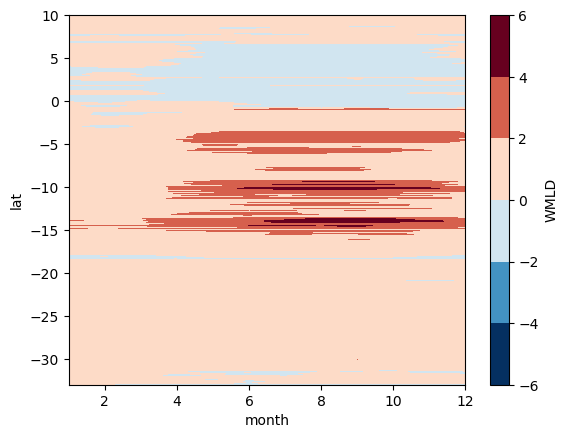

In [63]:
seasonality((WMLD_ds_.WMLD*86400).mean('lon',skipna=True)).plot.contourf(x='month')

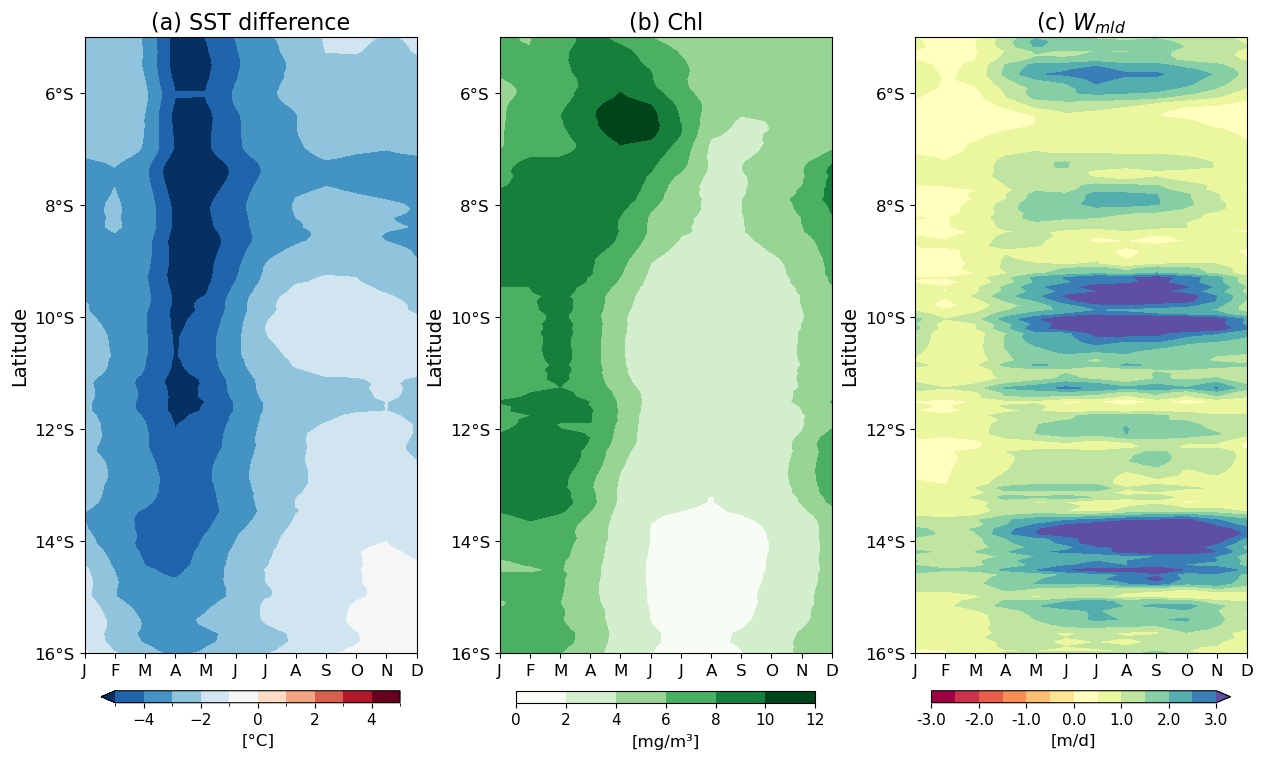

In [64]:
# Figure with 3 columns
WMLD_plot = seasonality((WMLD_ds_.WMLD*86400).mean('lon',skipna=True))
from cmocean import cm

rolls = 3
from matplotlib.ticker import FixedLocator
fig, ax = plt.subplots(1, 3, figsize=(15, 8), sharex=True)
plt.subplots_adjust(hspace=0.3, wspace=0.25)

# 1) SST
cf1 = CUI_in_season.sel(lat=slice(-17, -4)).rolling(lat=rolls, center=True).mean().plot.contourf(
    x='month', y='lat', cmap='RdBu_r', ax=ax[0], add_colorbar=False, vmin=-5,vmax=5,levels=11
)
ax[0].set_title('(a) SST difference', fontsize=16)
ax[0].set_ylabel('Latitude', fontsize=14)

# 2) Chlorophyll
cf2 = chl_season.chla.sel(lat=slice(-17, -4)).mean(dim='lon', skipna=True).rolling(lat=rolls, center=True).mean().plot.contourf(
    x='month', y='lat', cmap='Greens', ax=ax[1], add_colorbar=False
)
ax[1].set_title('(b) Chl', fontsize=16)
ax[1].set_ylabel('Latitude', fontsize=14)

# 3) Wmld
vmin, vmax = -3, 3
norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)
levels = np.linspace(vmin, vmax, 13)
cf3 = WMLD_plot.sel(lat=slice(-17, -4)).rolling(lat=rolls, center=True).mean().plot.contourf(
    x='month', y='lat', cmap='Spectral', norm=norm, levels=levels,
    add_colorbar=False, ax=ax[2]
)
ax[2].set_title('(c) $W_{mld}$', fontsize=16)
ax[2].set_ylabel('Latitude', fontsize=14)

# -------- Add horizontal colorbars below each axis --------
from matplotlib.ticker import FormatStrFormatter

def add_horizontal_cbar(fig, mappable, ax, label, shrink=0.9, pad_frac=0.08, fmt=None):
    left, bottom, width, height = ax.get_position().bounds
    cbar_h = 0.015
    cax = fig.add_axes([left + (1 - shrink) * width / 2, bottom - pad_frac * height, width * shrink, cbar_h])
    cbar = fig.colorbar(mappable, cax=cax, orientation='horizontal')
    if fmt is not None:
        cbar.ax.xaxis.set_major_formatter(FormatStrFormatter(fmt))
    cbar.set_label(label, fontsize=12)
    cbar.ax.tick_params(labelsize=11)
    return cbar

add_horizontal_cbar(fig, cf1, ax[0], '[°C]')
add_horizontal_cbar(fig, cf2, ax[1], '[mg/m³]')
# round Wmld colorbar ticks to 1 decimal
add_horizontal_cbar(fig, cf3, ax[2], '[m/d]', fmt='%.1f')

# -------- Format axes --------
# Set identical latitude limits so the upper tick is 5°S
for a in ax:
    # Show lat from 16°S up to 5°S (no inversion)
    a.set_ylim(-16, -5)

    # Custom ticks: start at -16, end at -6, or include -5 if you want
    yticks = np.arange(-16, -4, 2)   # [-16, -14, ..., -6]
    # If you prefer to include -5 explicitly, use:
    # yticks = np.concatenate([np.arange(-16, -6, 2), [-5]])

    a.yaxis.set_major_locator(FixedLocator(yticks))
    a.set_yticklabels([f"{-y:.0f}°S" for y in yticks], fontsize=12)

months = ['J','F','M','A','M','J','J','A','S','O','N','D']
for a in ax:
    a.set_xticks(range(1, 13))
    a.set_xticklabels(months, fontsize=12)
    a.set_xlabel('')

# plt.savefig('Figures/paper/EBUS_season.png', dpi=300, bbox_inches='tight')
plt.show()

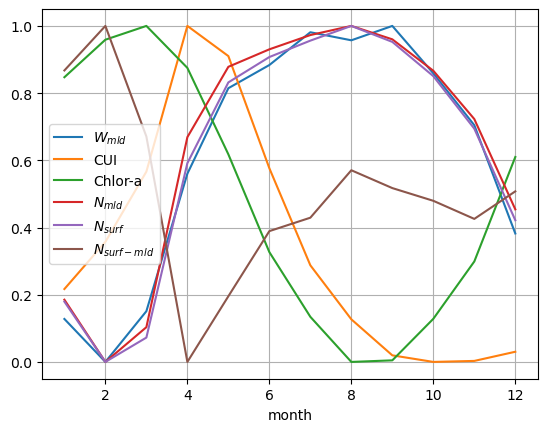

In [65]:

normalize(wmld.sel(lat=slice(-16, -5)).mean(dim='lat')).plot(label='$W_{mld}$')
normalize(CUI_season.sel(lat=slice(-16, -5)).mean(dim='lat')).plot(label='CUI')
normalize(chl_season.chla.sel(lat=slice(-16, -5)).mean(dim=('lat','lon'))).plot(label='Chlor-a')
normalize(N_season.Nitro_mld.sel(lat=slice(-16, -5)).mean(dim=('lat','lon'),skipna=True)).plot(label='$N_{mld}$')
normalize(N_season.Nitro_surf.sel(lat=slice(-16, -5)).mean(dim=('lat','lon'),skipna=True)).plot(label='$N_{surf}$')
normalize(Ndiff_season.sel(lat=slice(-16, -5)).mean(dim=('lat','lon'),skipna=True)).plot(label='$N_{surf-mld}$')
plt.grid()
plt.legend()

* include BEUTI vs Chlor

### Upwelling versus MLD

In [66]:
time = pd.date_range(start='1980-01', end='2016-01', freq='M')
MLD = loadmat("../../NHCS/Processed/WMLD_MLD.mat")

MLD_ds = xr.Dataset(
    data_vars={
        'MLD': (("time", "lat","lon"), MLD['MLD'].transpose(2, 1, 0)*expanded_mask* inshore_mask),
    },
    coords = {
        'lon':ds.lon_rho.compute().values[0,:],
        'lat':ds.lat_rho.compute().values[:,0],
        'time':time
}
)

MLD_ds

/tmp/ipykernel_2277849/2136443538.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  time = pd.date_range(start='1980-01', end='2016-01', freq='M')


<xarray.Dataset> Size: 1GB
Dimensions:  (time: 432, lat: 542, lon: 602)
Coordinates:
  * lon      (lon) float64 5kB -119.0 -118.9 -118.8 ... -69.03 -68.95 -68.87
  * lat      (lat) float64 4kB -33.0 -32.93 -32.86 -32.79 ... 9.869 9.951 10.03
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
Data variables:
    MLD      (time, lat, lon) float64 1GB nan nan nan nan ... nan nan nan nan

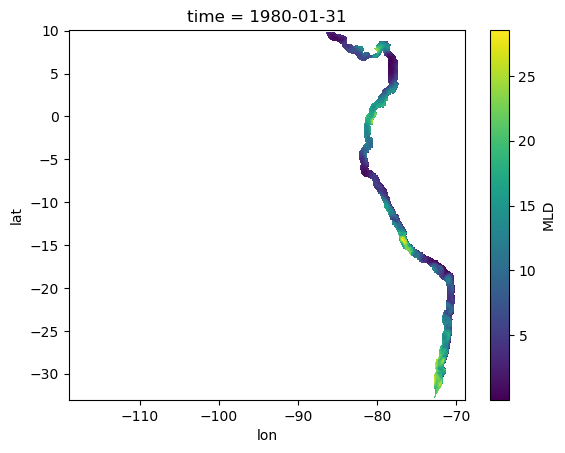

In [67]:
MLD_ds.MLD.isel(time=0).plot()

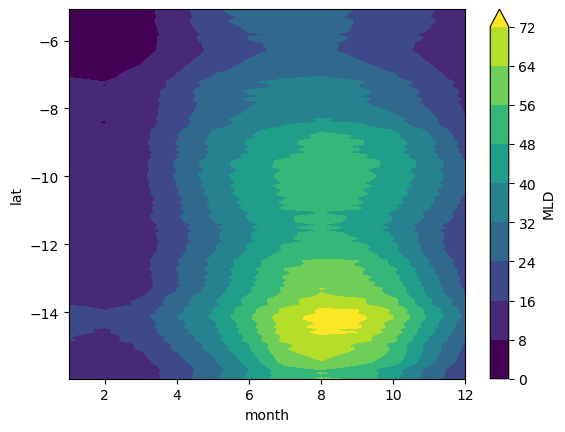

In [68]:
seasonality(MLD_ds).mean('lon').sel(lat=slice(-16,-5)).MLD.plot.contourf(x='month',levels=10,robust=True)

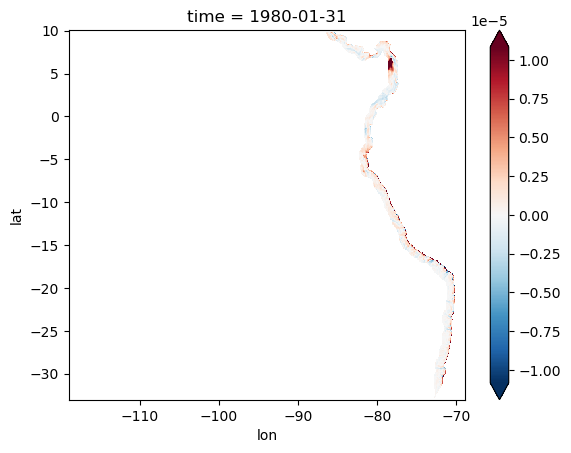

In [69]:
UP_MLD = WMLD_ds_.WMLD/MLD_ds.MLD
UP_MLD.isel(time=0).plot(robust=True)

Text(0.5, 1.0, 'W_mld/MLD')

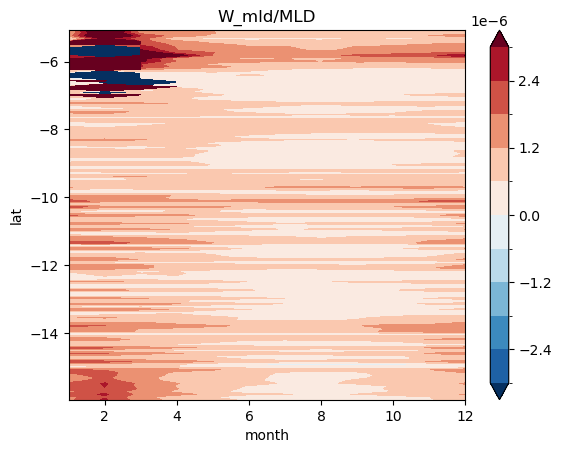

In [70]:
seasonality(UP_MLD).mean('lon',skipna=True).sel(lat=slice(-16,-5)).plot.contourf(x='month',levels=10,robust=True)
plt.title('W_mld/MLD')

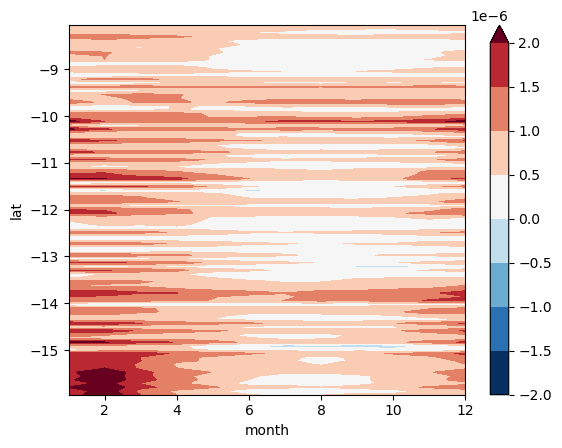

In [71]:
UP_season = seasonality(UP_MLD).mean('lon').sel(lat=slice(-16,-8))
UP_season.where(UP_season>-1e7,np.nan).plot.contourf(levels=10,x='month',robust=True)
# UP_season.plot.contourf(levels=10,x='month',robust=True)

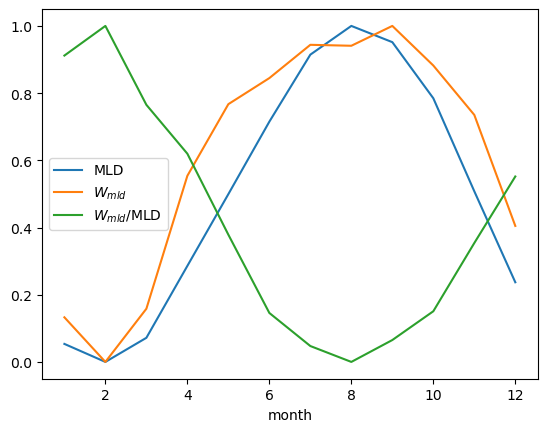

In [72]:
normalize(seasonality(MLD_ds).mean('lon').sel(lat=slice(-16,-8)).mean('lat').MLD).plot(label='MLD')
normalize(wmld.sel(lat=slice(-16, -8)).mean(dim='lat')).plot(label='$W_{mld}$')
normalize(UP_season.where(UP_season>-1e7,np.nan).mean('lat')).plot(label='$W_{mld}$/MLD')
plt.legend()

### Plot for the Paper

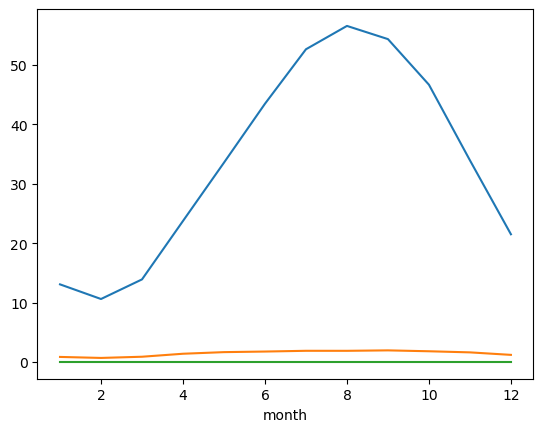

In [73]:
seasonality(MLD_ds).mean('lon').sel(lat=slice(-16,-8)).mean('lat').MLD.plot()
wmld.sel(lat=slice(-16, -8)).mean(dim='lat').plot()
seasonality(UP_MLD).mean('lon',skipna=True).sel(lat=slice(-16,-8)).mean(dim='lat').plot()

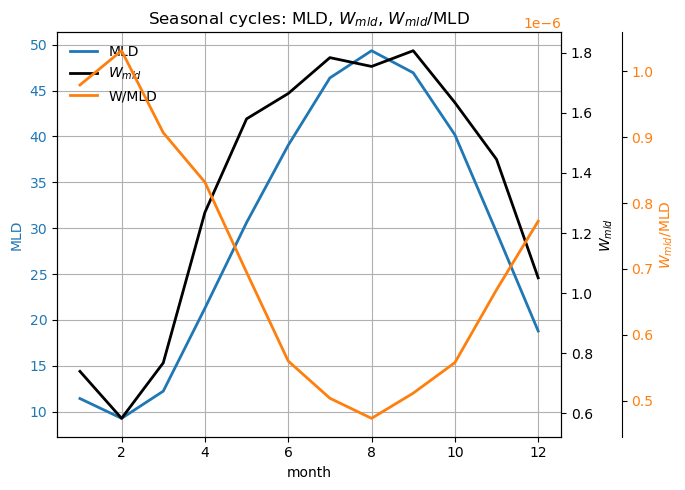

In [74]:
# Build the three series explicitly for clarity
months = ['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D']

s1 = seasonality(MLD_ds).mean('lon').sel(lat=slice(-16, -5)).mean('lat').MLD      # e.g., MLD seasonal cycle
s2 = wmld.sel(lat=slice(-16, -5)).mean('lat')                                     # e.g., wMLD
s3 = seasonality(UP_MLD).mean('lon', skipna=True).sel(lat=slice(-16, -7)).mean('lat')  # e.g., upwelling index

# Create base axes
fig, ax1 = plt.subplots(figsize=(7, 5))

# First series on ax1 (left y-axis)
h1 = s1.plot(ax=ax1, color='tab:blue', label='MLD', linewidth=2)
ax1.set_ylabel('MLD', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.grid(True)
# Second y-axis sharing x
ax2 = ax1.twinx()
h2 = s2.plot(ax=ax2, color='black', label='$W_{mld}$',  linewidth=2)
ax2.set_ylabel('$W_{mld}$', color='black')
ax2.tick_params(axis='y', labelcolor='black')

# Third y-axis: create a twin and offset its spine to avoid overlap
ax3 = ax1.twinx()
ax3.spines['right'].set_position(('axes', 1.12))  # shift outward
# Make the extra spine visible for newer Matplotlib
ax3.set_frame_on(True)
ax3.patch.set_visible(False)
for sp in ax3.spines.values():
    sp.set_visible(False)
ax3.spines['right'].set_visible(True)

h3 = s3.plot(ax=ax3, color='tab:orange', label='W/MLD',  linewidth=2)
ax3.set_ylabel('$W_{mld}$/MLD', color='tab:orange')
ax3.tick_params(axis='y', labelcolor='tab:orange')

# Shared x-label/title (xarray often sets a title; you can override)
ax1.set_xlabel(s1[s1.dims[0]].name if s1.dims else '')
ax1.set_title('Seasonal cycles: MLD, $W_{mld}$, $W_{mld}$/MLD')

# Build a combined legend
lines = []
labels = []
for h in (h1, h2, h3):
    # xarray returns a list of artists for line plots; handle both list/Line2D
    if isinstance(h, (list, tuple)):
        for _h in h:
            l = _h
            lines.append(l)
            labels.append(l.get_label())
    else:
        lines.append(h[0] if isinstance(h, (list, tuple)) else h)
        labels.append((h[0] if isinstance(h, (list, tuple)) else h).get_label())

ax1.legend(lines, labels, loc='upper left', frameon=False)
# ax1.set_xticklabels(months, fontsize=11)

plt.tight_layout()
plt.show()

* Even though there is less wind driven upwelling during February, there is more transport [W_mld/MLD] (1/s)

/tmp/ipykernel_2277849/3569798301.py:73: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


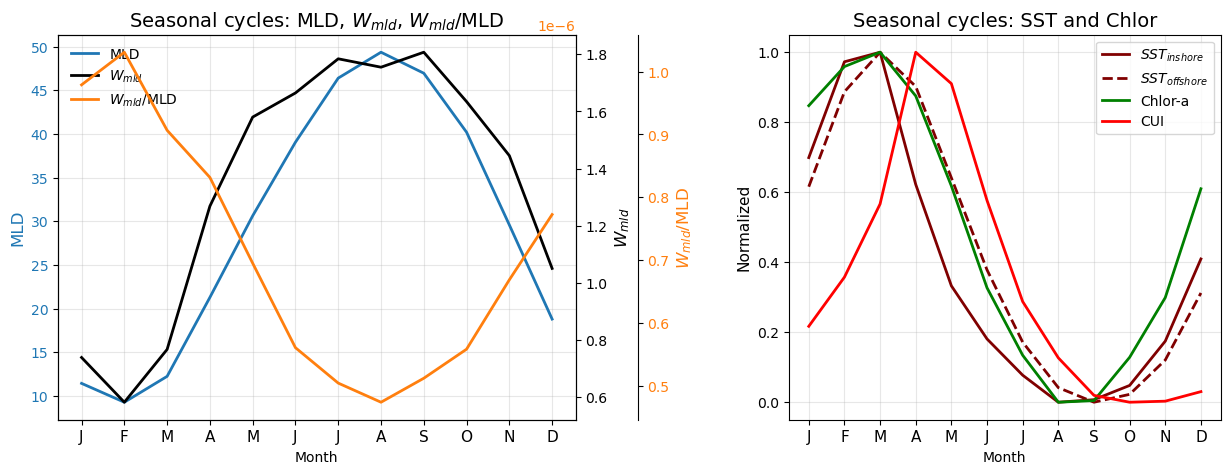

In [75]:
import numpy as np
import matplotlib.pyplot as plt

# Helper: ensure month coordinate is 1..12
def to_month_1_12(da):
    if 'month' in da.coords:
        m = da['month'].values
        if np.min(m) == 0 and np.max(m) == 11:
            da = da.assign_coords(month=(('month',), m + 1))
        return da
    if 'time' in da.coords:
        return (da
                .assign_coords(month=da['time'].dt.month)
                .swap_dims({'time': 'month'})
                .groupby('month').mean())
    raise ValueError("DataArray needs a 'month' or 'time' coordinate")

months_labels = ['J','F','M','A','M','J','J','A','S','O','N','D']
full_months = np.arange(1, 13)

# LEFT PANEL DATA
s1 = to_month_1_12(seasonality(MLD_ds).mean('lon').sel(lat=slice(-16, -5)).mean('lat').MLD).reindex(month=full_months)
s2 = to_month_1_12(wmld.sel(lat=slice(-16, -5)).mean('lat')).reindex(month=full_months)
s3 = to_month_1_12(seasonality(UP_MLD).mean('lon', skipna=True).sel(lat=slice(-16, -7)).mean('lat')).reindex(month=full_months)

# RIGHT PANEL DATA (normalized)
r1 = to_month_1_12(seasonality(SST_inshore.mean(dim='lon')).sel(lat=slice(-16,-5)).mean(dim='lat')).reindex(month=full_months)
r2 = to_month_1_12(seasonality(SST_offshore.mean(dim='lon')).sel(lat=slice(-16,-5)).mean(dim='lat')).reindex(month=full_months)
r3 = to_month_1_12(chl_season.chla.sel(lat=slice(-16, -5)).mean(dim=('lat','lon'))).reindex(month=full_months)
r4 = to_month_1_12(CUI_season.sel(lat=slice(-16, -5)).mean(dim='lat')).reindex(month=full_months)

r1n = normalize(r1); r2n = normalize(r2); r3n = normalize(r3); r4n = normalize(r4)

# FIGURE LAYOUT with wider gap
fig = plt.figure(figsize=(15, 5))
gs = fig.add_gridspec(nrows=1, ncols=2, width_ratios=[1.2, 1.0], wspace=0.45)

# LEFT: 3 y-axes
ax1 = fig.add_subplot(gs[0, 0])
l1, = ax1.plot(s1['month'], s1, color='tab:blue', linewidth=2, label='MLD')
ax1.set_ylabel('MLD', color='tab:blue',fontsize=12); ax1.tick_params(axis='y', labelcolor='tab:blue'); ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
l2, = ax2.plot(s2['month'], s2, color='black', linewidth=2, label='$W_{mld}$')
ax2.set_ylabel('$W_{mld}$', color='black',fontsize=12); ax2.tick_params(axis='y', labelcolor='black')

ax3 = ax1.twinx()
ax3.spines['right'].set_position(('axes', 1.12))
ax3.set_frame_on(True); ax3.patch.set_visible(False)
for sp in ax3.spines.values(): sp.set_visible(False)
ax3.spines['right'].set_visible(True)
l3, = ax3.plot(s3['month'], s3, color='tab:orange', linewidth=2, label='$W_{mld}$/MLD')
ax3.set_ylabel('$W_{mld}$/MLD', color='tab:orange',fontsize=12); ax3.tick_params(axis='y', labelcolor='tab:orange')

ax1.set_xticks(full_months); ax1.set_xticklabels(months_labels, fontsize=11); ax1.set_xlabel('Month')
ax1.set_title('Seasonal cycles: MLD, $W_{mld}$, $W_{mld}$/MLD',fontsize=14)
ax1.legend([l1, l2, l3], [l.get_label() for l in [l1, l2, l3]], loc='upper left', frameon=False)

# RIGHT: normalized series
axR = fig.add_subplot(gs[0, 1], sharex=ax1)
p1, = axR.plot(r1n['month'], r1n, label='$SST_{inshore}$', linewidth=2, color='maroon')
p2, = axR.plot(r2n['month'], r2n, label='$SST_{offshore}$', linewidth=2, linestyle='--', color='maroon')
p3, = axR.plot(r3n['month'], r3n, label='Chlor-a', color='green', linewidth=2)
p4, = axR.plot(r4n['month'], r4n, label='CUI', color='red', linewidth=2)

axR.set_xticks(full_months); axR.set_xticklabels(months_labels, fontsize=11)
axR.set_xlabel('Month'); axR.set_ylabel('Normalized', fontsize=11)
axR.grid(alpha=0.3); axR.set_title('Seasonal cycles: SST and Chlor',fontsize=14)

# Move right legend to the right side (outside)
axR.legend(loc='upper right')

plt.tight_layout()
# plt.savefig('Figures/paper/fig6_seasonal_prox_chlor_sst', dpi=300, bbox_inches='tight')
plt.show()

* This can also mean that 600km offshore is not enough offshore

#### Now including CUI, Chlor and BEUTI

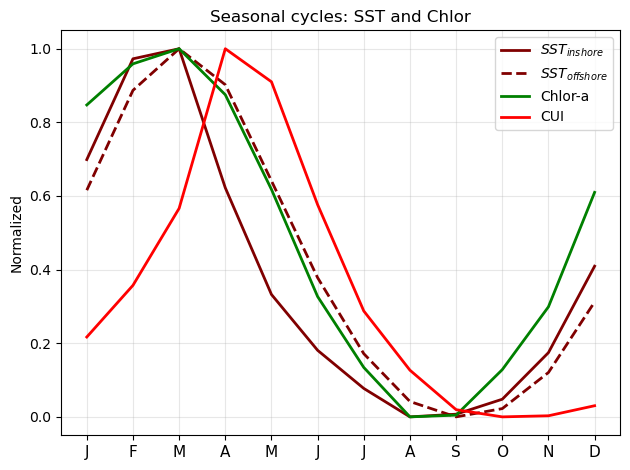

In [76]:
months = ['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D']

normalize(seasonality(SST_inshore.mean(dim='lon')).sel(lat=slice(-16,-5)).mean(dim='lat')).plot(label='$SST_{inshore}$',linewidth=2,color='maroon')
normalize(seasonality(SST_offshore.mean(dim='lon')).sel(lat=slice(-16,-5)).mean(dim='lat')).plot(label='$SST_{offshore}$',linewidth=2,linestyle='--',color='maroon')
normalize(chl_season.chla.sel(lat=slice(-16, -5)).mean(dim=('lat','lon'))).plot(label='Chlor-a',color='green',linewidth=2)
normalize(CUI_season.sel(lat=slice(-16, -5)).mean(dim='lat')).plot(label='CUI',color='red',linewidth=2)

ax = plt.gca()
ax.set_xticks(range(1, 13))
ax.set_xticklabels(months, fontsize=11)

# Cosmetics
plt.grid(alpha=0.3)
plt.legend()
plt.xlabel('')
plt.ylabel('Normalized')
plt.title('Seasonal cycles: SST and Chlor')
plt.tight_layout()
# plt.savefig('Figures/paper/SST_vs_Chl.png', dpi=300, bbox_inches='tight')

plt.show()

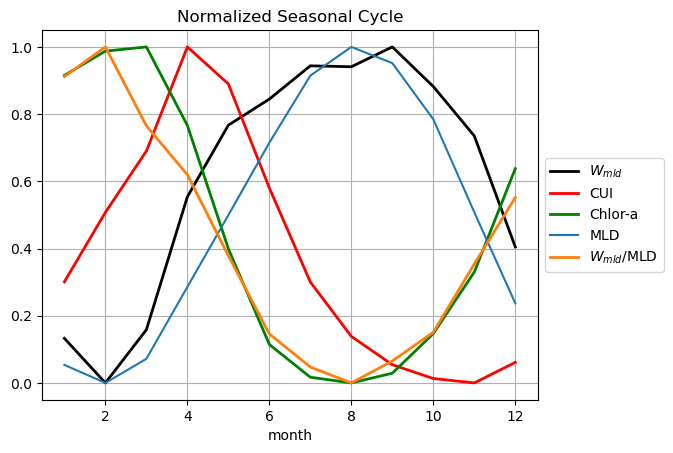

In [77]:
normalize(wmld.sel(lat=slice(-16, -8)).mean(dim='lat')).plot(label='$W_{mld}$',linewidth=2,color='black')
normalize(CUI_season.sel(lat=slice(-16, -8)).mean(dim='lat')).plot(label='CUI',color='red',linewidth=2)
normalize(chl_season.chla.sel(lat=slice(-16, -8)).mean(dim=('lat','lon'))).plot(label='Chlor-a',color='green',linewidth=2)

normalize(seasonality(MLD_ds).mean('lon').sel(lat=slice(-16,-8)).mean('lat').MLD).plot(label='MLD')
normalize(seasonality(UP_MLD).mean('lon', skipna=True).sel(lat=slice(-16, -8)).mean('lat')).plot(label='$W_{mld}$/MLD',color='tab:orange',linewidth=2)

plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.title('Normalized Seasonal Cycle')
plt.grid()

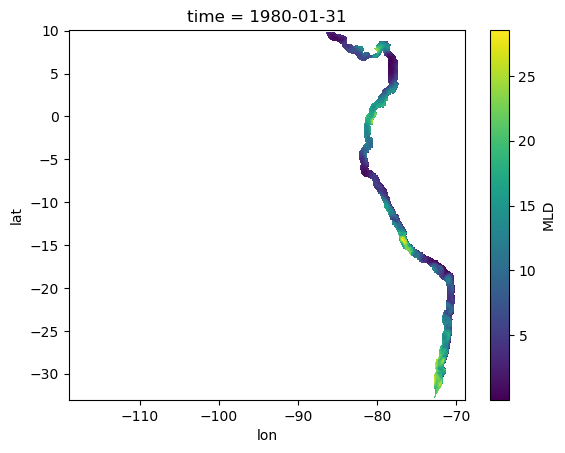

In [78]:
MLD_ds.isel(time=0).MLD.plot()

In [79]:
# Convertir a series y mantener el índice temporal
MLD = monthly_anomaly(MLD_ds.MLD.sel(lat=slice(-16,-5))).rolling(time=13,center=True).mean()
Chlor = monthly_anomaly(CHL.chla.sel(lat=slice(-16,-5))).rolling(time=13,center=True).mean()


MLD_pd = MLD.to_series().dropna()
Chlor_pd = Chlor.to_series().dropna()

# Unir por índice (tiempo)
df4 = pd.concat([MLD_pd, Chlor_pd], axis=1)
df4.columns = ['MLD', 'Chlor']
df4

,MLD,Chlor
time,,
1980-07-31,-0.126763,0.424036
1980-08-31,-0.272122,0.245752
1980-09-30,-0.454815,0.100002
1980-10-31,-0.271337,0.018717
1980-11-30,-0.334481,-0.011532
...,...,...
2015-02-28,-1.408616,-0.029671
2015-03-31,-1.593314,0.022649
2015-04-30,-1.420680,0.043958


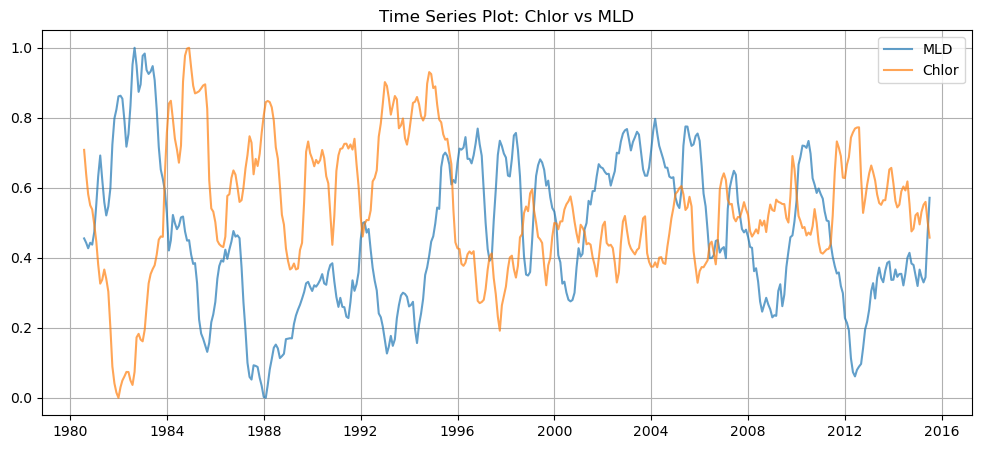


Top 3 cross-correlation peaks:
r = -0.658  |  lag = 1
r = -0.658  |  lag = -99
r = -0.655  |  lag = 2


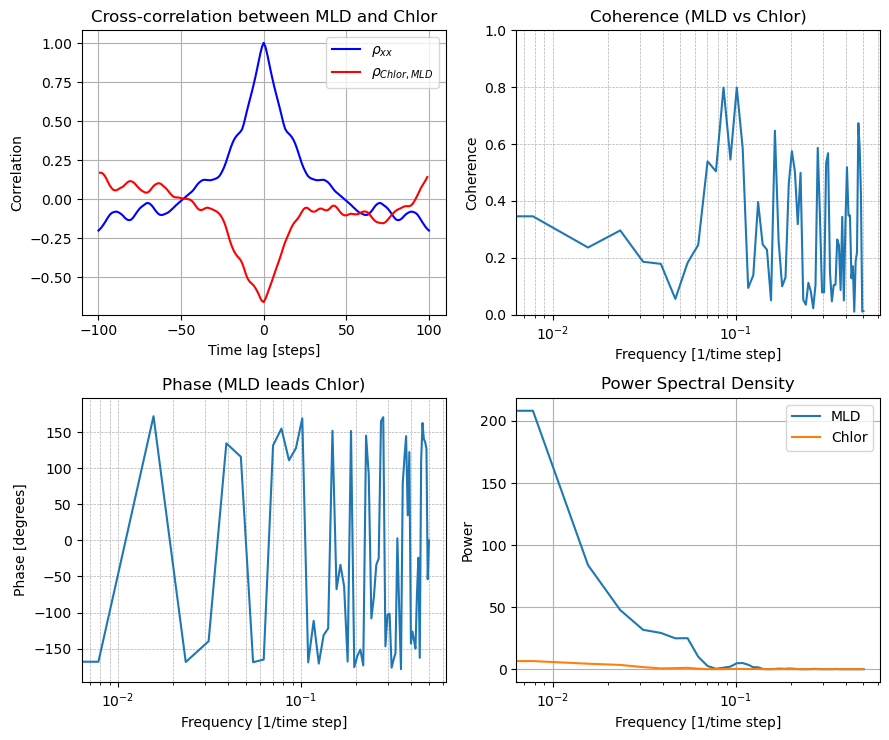

In [80]:
nperseg = 128
analyze_correlation_and_spectrum(df4, 'MLD', 'Chlor',lags=100, nperseg=nperseg, xlim=500)

* This tells us that Chlor leads MLD by 1 month. But as this has no physical meaning and the Lag0 is close to -0.658, then we will take the lag 0 and say that the Chlor and MLD interanual variability is strongly negatively correlated. 

## Spectral analysis

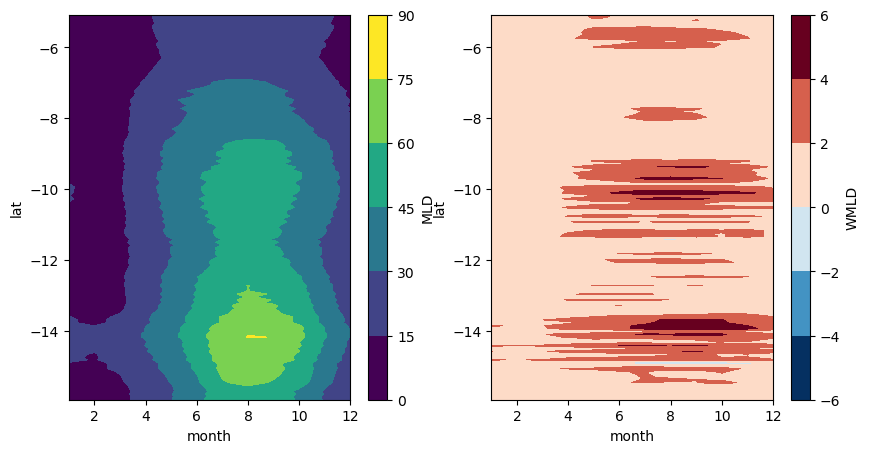

In [81]:

fig,ax = plt.subplots(1,2,figsize=(10,5))

seasonality(MLD_ds).mean('lon').sel(lat=slice(-16, -5)).MLD.plot.contourf(x='month',ax=ax[0])     # e.g., MLD seasonal cycle
wmld.sel(lat=slice(-16, -5)).plot.contourf(x='month',ax=ax[1])                                    # e.g., wMLD


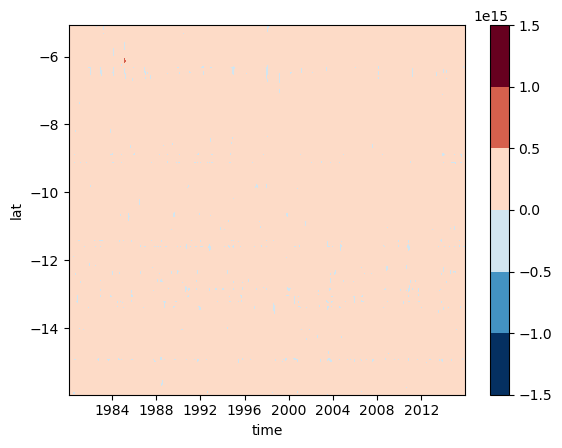

In [98]:
UP_MLD.sel(lat=slice(-16,-5)).mean(dim='lon').plot.contourf(x='time')

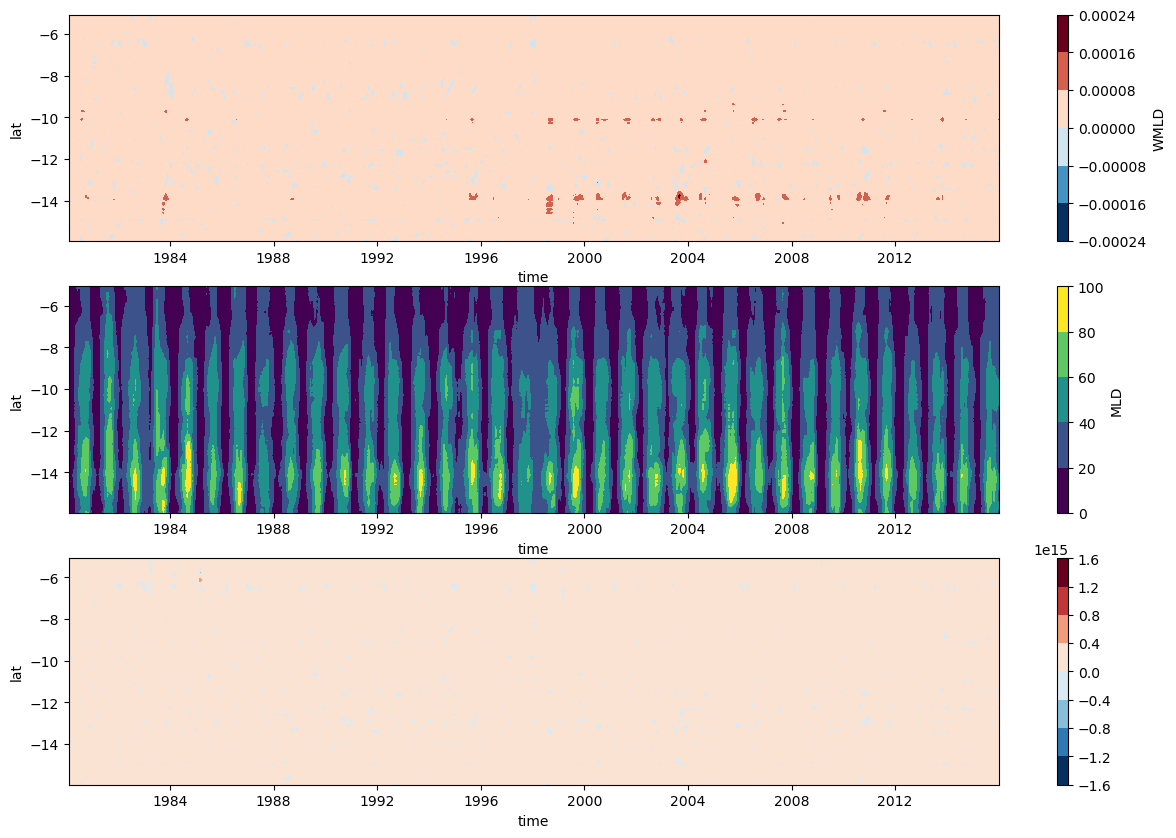

In [115]:
# WMLD_ds_.WMLD/MLD_ds.MLD
fig,ax=plt.subplots(3,1,figsize=(15,10))

WMLD_ds_.WMLD.mean(dim='lon').sel(lat=slice(-16,-5)).plot.contourf(x='time',ax=ax[0])
MLD_ds.MLD.mean(dim='lon').sel(lat=slice(-16,-5)).plot.contourf(x='time',ax=ax[1])
(WMLD_ds_.WMLD/MLD_ds.MLD).mean(dim='lon').sel(lat=slice(-16,-5)).plot.contourf(x='time',levels=10,ax=ax[2])


In [123]:
print(WMLD_ds_.WMLD.mean(dim='lon').sel(lat=slice(-16,-5)).min())
print(MLD_ds.MLD.mean(dim='lon').sel(lat=slice(-16,-5)).min())
# (WMLD_ds_.WMLD/MLD_ds.MLD).mean(dim='lon').sel(lat=slice(-16,-5))

<xarray.DataArray 'WMLD' ()> Size: 8B
array(-0.0001365)
<xarray.DataArray 'MLD' ()> Size: 8B
array(97.13095828)


In [131]:
WMLD_ds_.WMLD.sel(lat=slice(-16,-5)).mean(dim='lon').min() / MLD_ds.MLD.sel(lat=slice(-16,-5)).mean(dim='lon').min()

<xarray.DataArray ()> Size: 8B
array(-0.01886301)

In [136]:
ETI = (WMLD_ds_.WMLD/MLD_ds.MLD).mean(dim='lon').sel(lat=slice(-16,-5))
ETI

<xarray.DataArray (time: 432, lat: 134)> Size: 463kB
array([[ 1.84027258e-06,  1.90366943e-06,  2.00237973e-06, ...,
         1.39785852e-06,  1.32579428e-06,  1.31342490e-06],
       [ 2.60348367e-06,  2.30971579e-06,  2.13758897e-06, ...,
         1.52710844e-06,  1.28076037e-06,  9.21903193e-07],
       [ 2.94993315e-06,  2.74923141e-06,  3.48850896e-06, ...,
         1.55875924e-06,  1.34710554e-06,  1.01676773e-06],
       ...,
       [ 4.58819703e-07,  9.35753093e-08,  4.11302564e-07, ...,
         8.45978492e-07,  6.57106091e-07,  5.61195958e-07],
       [ 5.63009352e-07,  1.06372286e-06,  1.39075777e-06, ...,
        -1.16923665e-07,  1.64641102e-07,  2.38132536e-07],
       [ 7.59791886e-07,  4.21877528e-07,  8.80215196e-07, ...,
         1.13496193e-06,  6.82993992e-07,  3.41320671e-07]])
Coordinates:
  * lat      (lat) float64 1kB -15.95 -15.87 -15.79 ... -5.242 -5.159 -5.076
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31

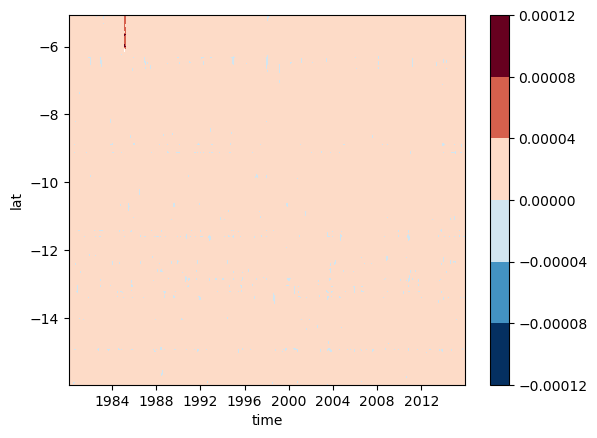

In [197]:
lower = 1e-7
upper = 1e-4

mask_mag = (np.abs(ETI) >= lower) & (np.abs(ETI) <= upper)
ETI = (WMLD_ds_.WMLD/MLD_ds.MLD)
ETI_sel = ETI.where(mask_mag)

ETI_sel.mean(dim='lon').sel(lat=slice(-16,-5)).plot.contourf(x='time')


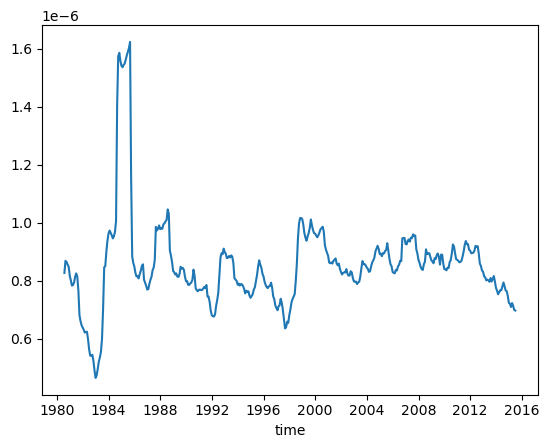

In [198]:
ETI_sel.mean(dim='lon').sel(lat=slice(-16,-5)).mean(dim='lat').rolling(time=13,center=True).mean().plot()

In [203]:
# Convertir a series y mantener el índice temporal
ETIs = monthly_anomaly(ETI_sel.sel(lat=slice(-16,-5))).rolling(time=13,center=True).mean()
Chlor = monthly_anomaly(CHL.chla.sel(lat=slice(-16,-5))).rolling(time=13,center=True).mean()


ETI_pd = ETIs.to_series().dropna()
Chlor_pd = Chlor.to_series().dropna()

# Unir por índice (tiempo)
df5 = pd.concat([ETI_pd, Chlor_pd], axis=1)
df5.columns = ['ETI', 'Chlor']
df5

,ETI,Chlor
time,,
1980-07-31,-3.444083e-08,0.424036
1980-08-31,5.598313e-09,0.245752
1980-09-30,1.245782e-08,0.100002
1980-10-31,1.500338e-08,0.018717
1980-11-30,1.799503e-08,-0.011532
...,...,...
2015-02-28,-1.086386e-07,-0.029671
2015-03-31,-1.004066e-07,0.022649
2015-04-30,-1.128559e-07,0.043958


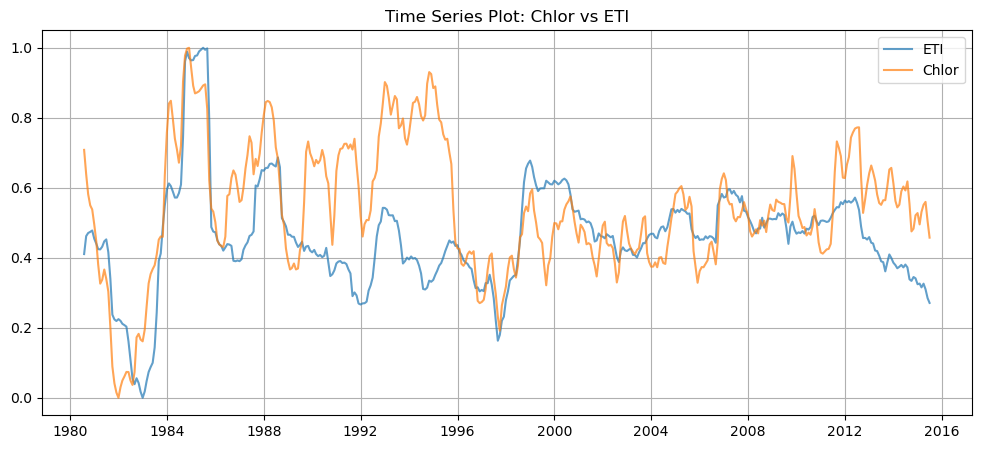


Top 3 cross-correlation peaks:
r = 0.550  |  lag = 2
r = 0.549  |  lag = 1
r = 0.549  |  lag = -99


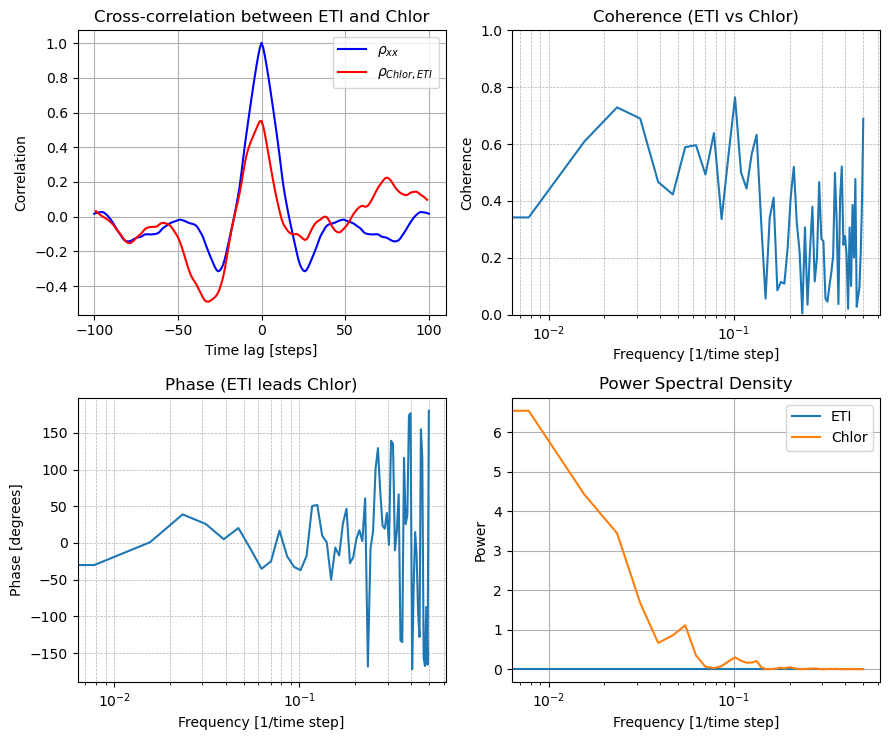

In [204]:
nperseg = 128
analyze_correlation_and_spectrum(df5, 'ETI', 'Chlor',lags=100, nperseg=nperseg, xlim=500)

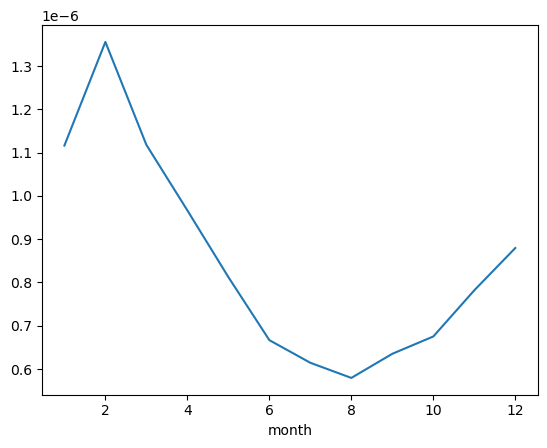

In [206]:
seasonality(ETI_sel.mean(dim='lon').sel(lat=slice(-16,-5)).mean(dim='lat')).plot()

/tmp/ipykernel_2277849/1667398831.py:70: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


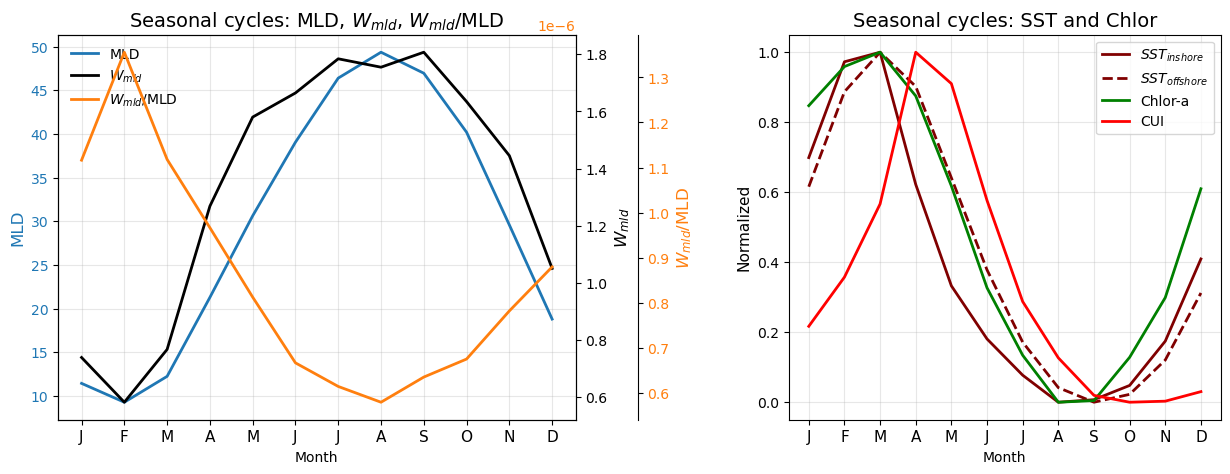

In [207]:
# Helper: ensure month coordinate is 1..12
def to_month_1_12(da):
    if 'month' in da.coords:
        m = da['month'].values
        if np.min(m) == 0 and np.max(m) == 11:
            da = da.assign_coords(month=(('month',), m + 1))
        return da
    if 'time' in da.coords:
        return (da
                .assign_coords(month=da['time'].dt.month)
                .swap_dims({'time': 'month'})
                .groupby('month').mean())
    raise ValueError("DataArray needs a 'month' or 'time' coordinate")

months_labels = ['J','F','M','A','M','J','J','A','S','O','N','D']
full_months = np.arange(1, 13)

# LEFT PANEL DATA
s1 = to_month_1_12(seasonality(MLD_ds).mean('lon').sel(lat=slice(-16, -5)).mean('lat').MLD).reindex(month=full_months)
s2 = to_month_1_12(wmld.sel(lat=slice(-16, -5)).mean('lat')).reindex(month=full_months)
s3 = to_month_1_12(seasonality(ETI_sel.mean(dim='lon').sel(lat=slice(-16,-5)).mean(dim='lat'))).reindex(month=full_months)

# RIGHT PANEL DATA (normalized)
r1 = to_month_1_12(seasonality(SST_inshore.mean(dim='lon')).sel(lat=slice(-16,-5)).mean(dim='lat')).reindex(month=full_months)
r2 = to_month_1_12(seasonality(SST_offshore.mean(dim='lon')).sel(lat=slice(-16,-5)).mean(dim='lat')).reindex(month=full_months)
r3 = to_month_1_12(chl_season.chla.sel(lat=slice(-16, -5)).mean(dim=('lat','lon'))).reindex(month=full_months)
r4 = to_month_1_12(CUI_season.sel(lat=slice(-16, -5)).mean(dim='lat')).reindex(month=full_months)

r1n = normalize(r1); r2n = normalize(r2); r3n = normalize(r3); r4n = normalize(r4)

# FIGURE LAYOUT with wider gap
fig = plt.figure(figsize=(15, 5))
gs = fig.add_gridspec(nrows=1, ncols=2, width_ratios=[1.2, 1.0], wspace=0.45)

# LEFT: 3 y-axes
ax1 = fig.add_subplot(gs[0, 0])
l1, = ax1.plot(s1['month'], s1, color='tab:blue', linewidth=2, label='MLD')
ax1.set_ylabel('MLD', color='tab:blue',fontsize=12); ax1.tick_params(axis='y', labelcolor='tab:blue'); ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
l2, = ax2.plot(s2['month'], s2, color='black', linewidth=2, label='$W_{mld}$')
ax2.set_ylabel('$W_{mld}$', color='black',fontsize=12); ax2.tick_params(axis='y', labelcolor='black')

ax3 = ax1.twinx()
ax3.spines['right'].set_position(('axes', 1.12))
ax3.set_frame_on(True); ax3.patch.set_visible(False)
for sp in ax3.spines.values(): sp.set_visible(False)
ax3.spines['right'].set_visible(True)
l3, = ax3.plot(s3['month'], s3, color='tab:orange', linewidth=2, label='$W_{mld}$/MLD')
ax3.set_ylabel('$W_{mld}$/MLD', color='tab:orange',fontsize=12); ax3.tick_params(axis='y', labelcolor='tab:orange')

ax1.set_xticks(full_months); ax1.set_xticklabels(months_labels, fontsize=11); ax1.set_xlabel('Month')
ax1.set_title('Seasonal cycles: MLD, $W_{mld}$, $W_{mld}$/MLD',fontsize=14)
ax1.legend([l1, l2, l3], [l.get_label() for l in [l1, l2, l3]], loc='upper left', frameon=False)

# RIGHT: normalized series
axR = fig.add_subplot(gs[0, 1], sharex=ax1)
p1, = axR.plot(r1n['month'], r1n, label='$SST_{inshore}$', linewidth=2, color='maroon')
p2, = axR.plot(r2n['month'], r2n, label='$SST_{offshore}$', linewidth=2, linestyle='--', color='maroon')
p3, = axR.plot(r3n['month'], r3n, label='Chlor-a', color='green', linewidth=2)
p4, = axR.plot(r4n['month'], r4n, label='CUI', color='red', linewidth=2)

axR.set_xticks(full_months); axR.set_xticklabels(months_labels, fontsize=11)
axR.set_xlabel('Month'); axR.set_ylabel('Normalized', fontsize=11)
axR.grid(alpha=0.3); axR.set_title('Seasonal cycles: SST and Chlor',fontsize=14)

# Move right legend to the right side (outside)
axR.legend(loc='upper right')

plt.tight_layout()
# plt.savefig('Figures/paper/fig6_seasonal_prox_chlor_sst', dpi=300, bbox_inches='tight')
plt.show()

### SST inshore and SST offshore

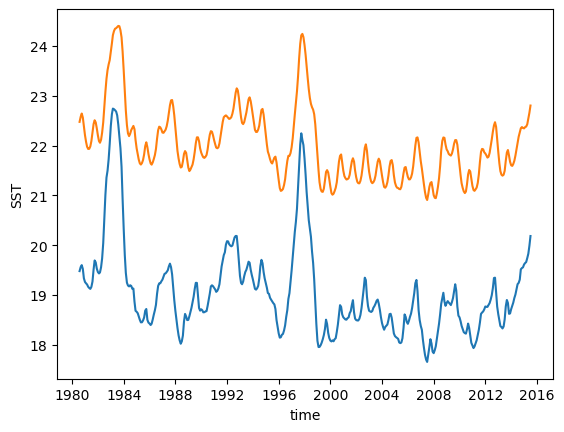

In [213]:
# ETIs = monthly_anomaly(ETI_sel.sel(lat=slice(-16,-5))).rolling(time=13,center=True).mean()
# Chlor = monthly_anomaly(CHL.chla.sel(lat=slice(-16,-5))).rolling(time=13,center=True).mean()

SST_inshore.mean(dim='lon').sel(lat=slice(-16,-5)).mean(dim='lat').rolling(time=13,center=True).mean().plot()
SST_offshore.mean(dim='lon').sel(lat=slice(-16,-5)).mean(dim='lat').rolling(time=13,center=True).mean().plot()

In [217]:
SST_in = monthly_anomaly(SST_inshore.sel(lat=slice(-16,-5))).rolling(time=13,center=True).mean()
Chlor = monthly_anomaly(CHL.chla.sel(lat=slice(-16,-5))).rolling(time=13,center=True).mean()


SSTin_pd = SST_in.to_series().dropna()
Chlor_pd = Chlor.to_series().dropna()

# Unir por índice (tiempo)
df6 = pd.concat([SSTin_pd, Chlor_pd], axis=1)
df6.columns = ['SST_in', 'Chlor']
df6
#-------------------
SST_off = monthly_anomaly(SST_offshore.sel(lat=slice(-16,-5))).rolling(time=13,center=True).mean()

SSToff_pd = SST_in.to_series().dropna()

# Unir por índice (tiempo)
df7 = pd.concat([SSTin_pd, Chlor_pd], axis=1)
df7.columns = ['SST_off', 'Chlor']
df7


,SST_off,Chlor
time,,
1980-07-31,0.256040,0.424036
1980-08-31,0.230657,0.245752
1980-09-30,0.259900,0.100002
1980-10-31,0.332611,0.018717
1980-11-30,0.261054,-0.011532
...,...,...
2015-02-28,0.703652,-0.029671
2015-03-31,0.780439,0.022649
2015-04-30,0.851908,0.043958


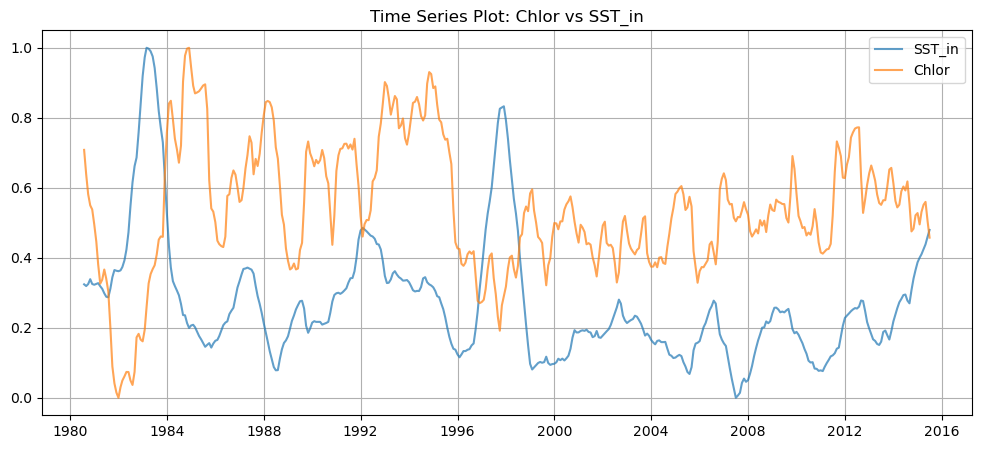


Top 3 cross-correlation peaks:
r = -0.434  |  lag = 10
r = -0.433  |  lag = 11
r = -0.428  |  lag = 12


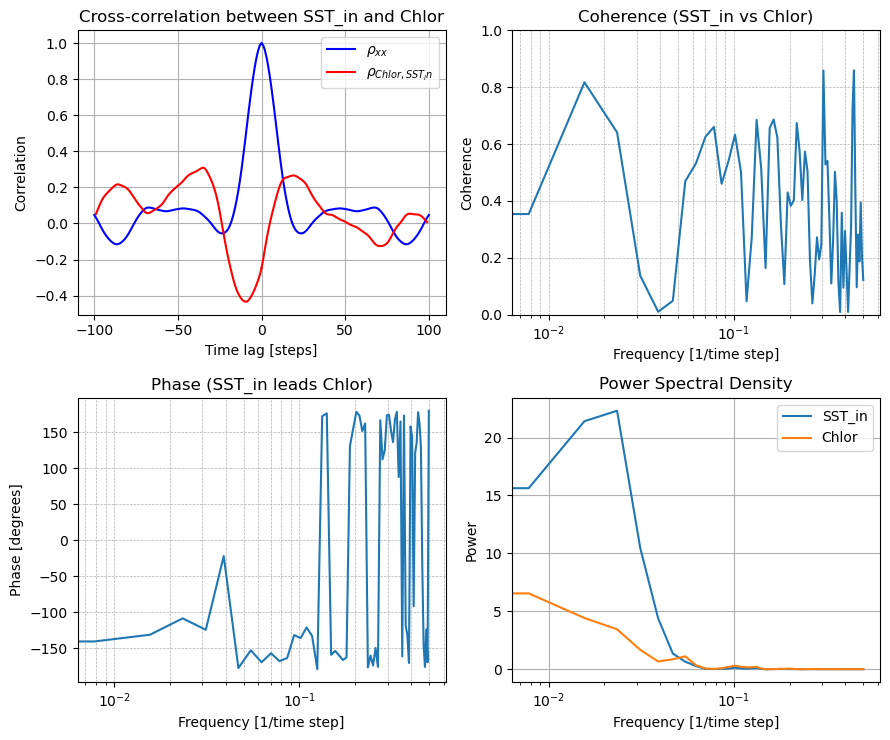

In [216]:
nperseg = 128
analyze_correlation_and_spectrum(df6, 'SST_in', 'Chlor',lags=100, nperseg=nperseg, xlim=500)

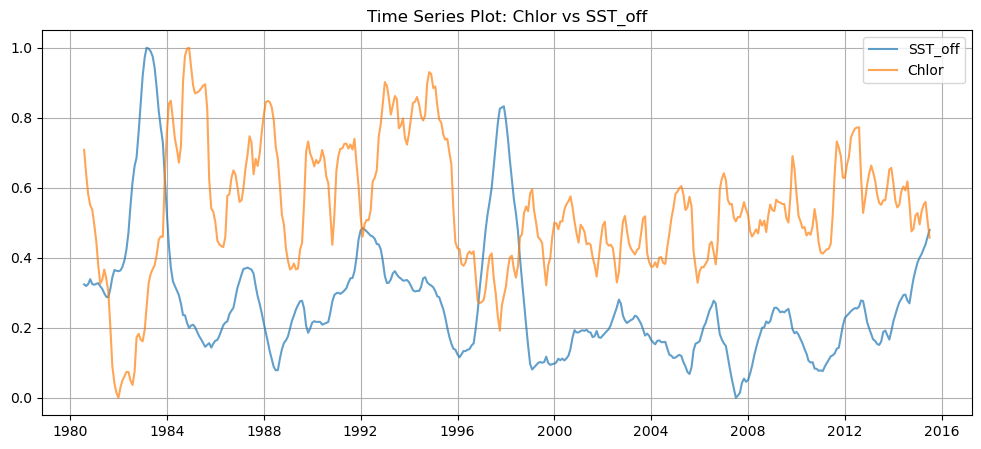


Top 3 cross-correlation peaks:
r = -0.434  |  lag = 10
r = -0.433  |  lag = 11
r = -0.428  |  lag = 12


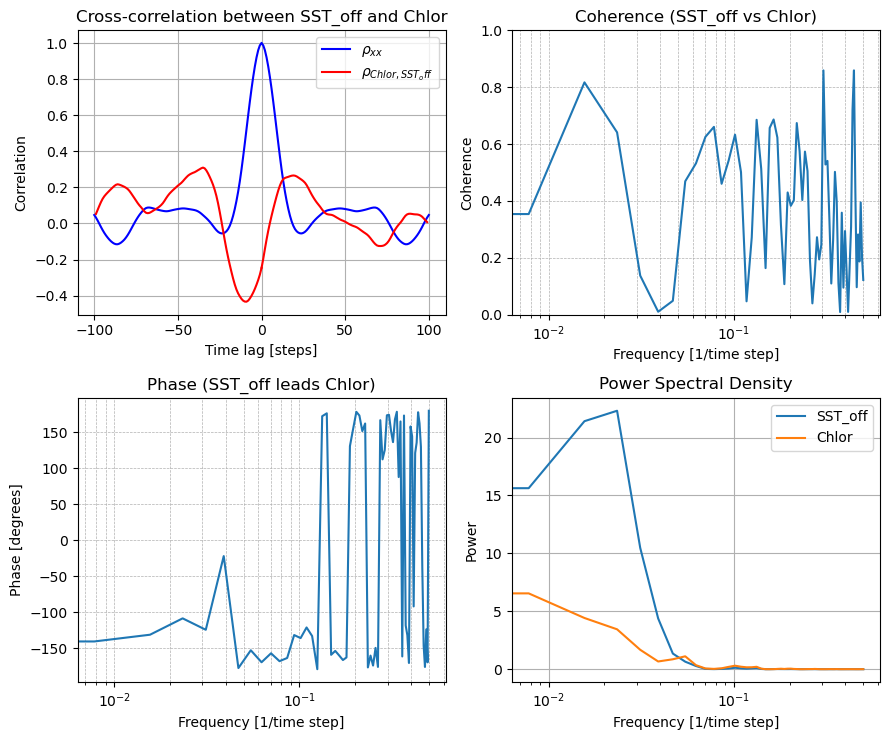

In [218]:
nperseg = 128
analyze_correlation_and_spectrum(df7, 'SST_off', 'Chlor',lags=100, nperseg=nperseg, xlim=500)